In [1]:
"""
Heart Disease Prediction — Data Mining (BAA5073)
Complete Pipeline: Preprocessing, Model Training, Hyperparameter Tuning,
                   Evaluation & Comparison

Dataset: Heart Failure Prediction Dataset
Source: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction
Features: 11 clinical features, 1 binary target (HeartDisease)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import matplotlib.ticker as mticker
from scipy.stats import pointbiserialr
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                     cross_val_predict, learning_curve,
                                     GridSearchCV)
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

RANDOM_STATE = 42

In [2]:
# =====================================================================
# 1. DATA LOADING
# =====================================================================
df = pd.read_csv('heart.csv')
print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Target distribution:\n{df['HeartDisease'].value_counts()}\n")


Dataset loaded: 918 rows, 12 columns
Target distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64



In [3]:
# =====================================================================
# 2. bASIC DATASET OVERVIEW
# =====================================================================
print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"\nTotal Instances : {df.shape[0]}")
print(f"Total Features  : {df.shape[1] - 1} (+ 1 target)")
print(f"\nColumn Data Types:")
print(df.dtypes)
print(f"\nDescriptive Statistics (Numeric Features):")
df.describe().T

DATASET OVERVIEW

Total Instances : 918
Total Features  : 11 (+ 1 target)

Column Data Types:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

Descriptive Statistics (Numeric Features):


,count,mean,std,min,25%,50%,75%,max
Age,918.0000,53.5109,9.4326,28.0000,47.0000,54.0000,60.0000,77.0000
RestingBP,918.0000,132.3965,18.5142,0.0000,120.0000,130.0000,140.0000,200.0000
Cholesterol,918.0000,198.7996,109.3841,0.0000,173.2500,223.0000,267.0000,603.0000
FastingBS,918.0000,0.2331,0.4230,0.0000,0.0000,0.0000,0.0000,1.0000
MaxHR,918.0000,136.8094,25.4603,60.0000,120.0000,138.0000,156.0000,202.0000
Oldpeak,918.0000,0.8874,1.0666,-2.6000,0.0000,0.6000,1.5000,6.2000
HeartDisease,918.0000,0.5534,0.4974,0.0000,0.0000,1.0000,1.0000,1.0000


In [4]:
# =====================================================================
# 3. DATA QUALITY CHECK
# =====================================================================
print("=" * 55)
print("DATA QUALITY ASSESSMENT")
print("=" * 55)

# Missing values
print("\n1. Missing Values per Column:")
missing = df.isnull().sum()
print(missing[missing >= 0].to_string())
print(f"\n→ Total missing values: {df.isnull().sum().sum()}")

# Duplicate rows
print(f"\n2. Duplicate Rows: {df.duplicated().sum()}")

# Zero value detection in medical columns (clinically impossible zeros)
print("\n3. Clinically Impossible Zero Values:")
zero_cholesterol = (df['Cholesterol'] == 0).sum()
zero_bp = (df['RestingBP'] == 0).sum()
print(f"   Cholesterol = 0  : {zero_cholesterol} rows ({zero_cholesterol/len(df)*100:.1f}%)")
print(f"   RestingBP  = 0   : {zero_bp} rows ({zero_bp/len(df)*100:.1f}%)")
print("\n→ NOTE: Cholesterol=0 and RestingBP=0 are medically impossible.")
print("   These are treated as missing values and will be imputed.")

DATA QUALITY ASSESSMENT

1. Missing Values per Column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0

→ Total missing values: 0

2. Duplicate Rows: 0

3. Clinically Impossible Zero Values:
   Cholesterol = 0  : 172 rows (18.7%)
   RestingBP  = 0   : 1 rows (0.1%)

→ NOTE: Cholesterol=0 and RestingBP=0 are medically impossible.
   These are treated as missing values and will be imputed.


In [5]:
# =====================================================================
# 4. DATA CLEANING
# =====================================================================
# 4a. Remove clinically impossible RestingBP = 0 (1 row)
bp_zero = (df['RestingBP'] == 0).sum()
df = df[df['RestingBP'] > 0].reset_index(drop=True)
print(f"Removed {bp_zero} row(s) with RestingBP = 0")

# 4b. Mark Cholesterol = 0 as missing (coded zeros, not real values)
chol_zero = (df['Cholesterol'] == 0).sum()
df['Cholesterol'] = df['Cholesterol'].replace(0, np.nan)
print(f"Cholesterol = 0 in {chol_zero} rows ({chol_zero/len(df)*100:.1f}%) — marked as missing")


Removed 1 row(s) with RestingBP = 0
Cholesterol = 0 in 171 rows (18.6%) — marked as missing


In [6]:
# =====================================================================
# 5. KNN IMPUTATION FOR MISSING CHOLESTEROL
# =====================================================================
# KNN imputation uses all clinical features (excluding the target variable)
# to find the 5 most similar patients and averages their cholesterol values.
# The target variable is excluded to prevent data leakage.

cat_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
le_dict = {}

df_impute = df.copy()
for col in cat_cols:
    le = LabelEncoder()
    df_impute[col] = le.fit_transform(df_impute[col])
    le_dict[col] = le

# Impute using only clinical features (exclude HeartDisease)
features_for_impute = [c for c in df_impute.columns if c != 'HeartDisease']
target_saved = df_impute['HeartDisease'].copy()

imputer = KNNImputer(n_neighbors=5)
df_impute[features_for_impute] = imputer.fit_transform(df_impute[features_for_impute])
df_impute['HeartDisease'] = target_saved

# Decode categoricals back
for col in cat_cols:
    df_impute[col] = le_dict[col].inverse_transform(df_impute[col].round().astype(int))

df_clean = df_impute.copy()
print(f"\nKNN imputation complete. Clean dataset: {df_clean.shape[0]} rows")
print(f"Cholesterol after imputation — Mean: {df_clean['Cholesterol'].mean():.1f}, "
      f"Std: {df_clean['Cholesterol'].std():.1f}")



KNN imputation complete. Clean dataset: 917 rows
Cholesterol after imputation — Mean: 245.0, Std: 54.7


In [7]:
# =====================================================================
# 6. OUTLIER ANALYSIS
# =====================================================================
print(f"\nOutlier Analysis (IQR Method):")
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

for col in numeric_features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    print(f"  {col:15s}: {outliers:3d} outliers  (range: {lower:.1f} to {upper:.1f})")

# Outliers are retained as they represent clinically plausible extreme values.
print("  -> Outliers retained (clinically plausible extreme values)")


Outlier Analysis (IQR Method):
  Age            :   0 outliers  (range: 27.5 to 79.5)
  RestingBP      :  27 outliers  (range: 90.0 to 170.0)
  Cholesterol    :  28 outliers  (range: 120.5 to 364.5)
  MaxHR          :   2 outliers  (range: 66.0 to 210.0)
  Oldpeak        :  16 outliers  (range: -2.2 to 3.8)
  -> Outliers retained (clinically plausible extreme values)


In [8]:
# =====================================================================
# 7. MULTICOLLINEARITY CHECK (VIF)
# =====================================================================
print(f"\nVariance Inflation Factor (VIF):")
df_vif = df_clean[numeric_features].copy()

for col in df_vif.columns:
    X_vif = df_vif.drop(columns=[col])
    y_vif = df_vif[col]
    r2 = LinearRegression().fit(X_vif, y_vif).score(X_vif, y_vif)
    vif = 1 / (1 - r2) if r2 < 1 else float('inf')
    print(f"  {col:15s}: VIF = {vif:.2f}")
print("  -> All VIF values < 5, no multicollinearity issues")



Variance Inflation Factor (VIF):
  Age            : VIF = 1.29
  RestingBP      : VIF = 1.10
  Cholesterol    : VIF = 1.01
  MaxHR          : VIF = 1.18
  Oldpeak        : VIF = 1.09
  -> All VIF values < 5, no multicollinearity issues


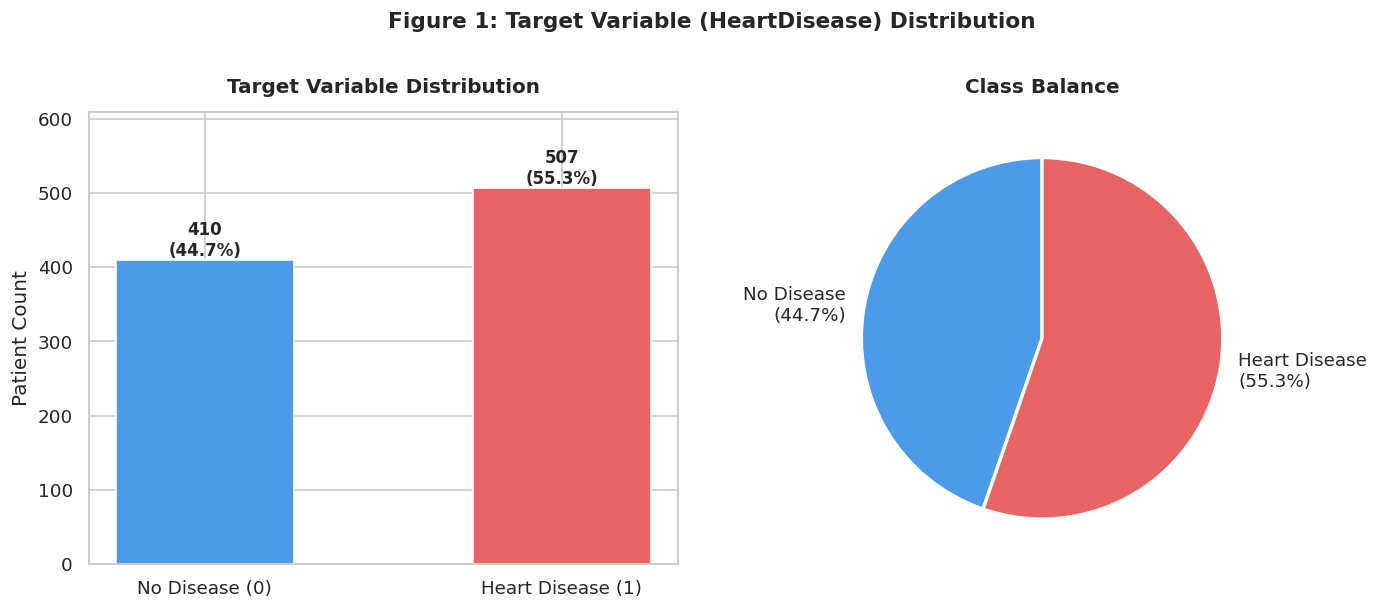


→ Class distribution: 507 Heart Disease (55.3%) vs 410 No Disease (44.7%)


In [9]:
# =====================================================================
# 8. CLASS DISTRIBUTION
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
counts = df_clean['HeartDisease'].value_counts().sort_index()
axes[0].bar(['No Disease (0)', 'Heart Disease (1)'],
            counts.values,
            color=['#4c9be8', '#e86464'], edgecolor='white', width=0.5)
axes[0].set_title('Target Variable Distribution', fontweight='bold', pad=12)
axes[0].set_ylabel('Patient Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, f'{v}\n({v/len(df_clean)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, max(counts.values) * 1.2)

# Pie chart
axes[1].pie(counts.values,
            labels=[f'No Disease\n({counts[0]/len(df_clean)*100:.1f}%)',
                    f'Heart Disease\n({counts[1]/len(df_clean)*100:.1f}%)'],
            colors=['#4c9be8', '#e86464'],
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Balance', fontweight='bold', pad=12)

plt.suptitle('Figure 1: Target Variable (HeartDisease) Distribution',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_class_distribution.png', bbox_inches='tight')
plt.show()

print(f"\n→ Class distribution: {counts[1]} Heart Disease ({counts[1]/len(df_clean)*100:.1f}%)"
      f" vs {counts[0]} No Disease ({counts[0]/len(df_clean)*100:.1f}%)")

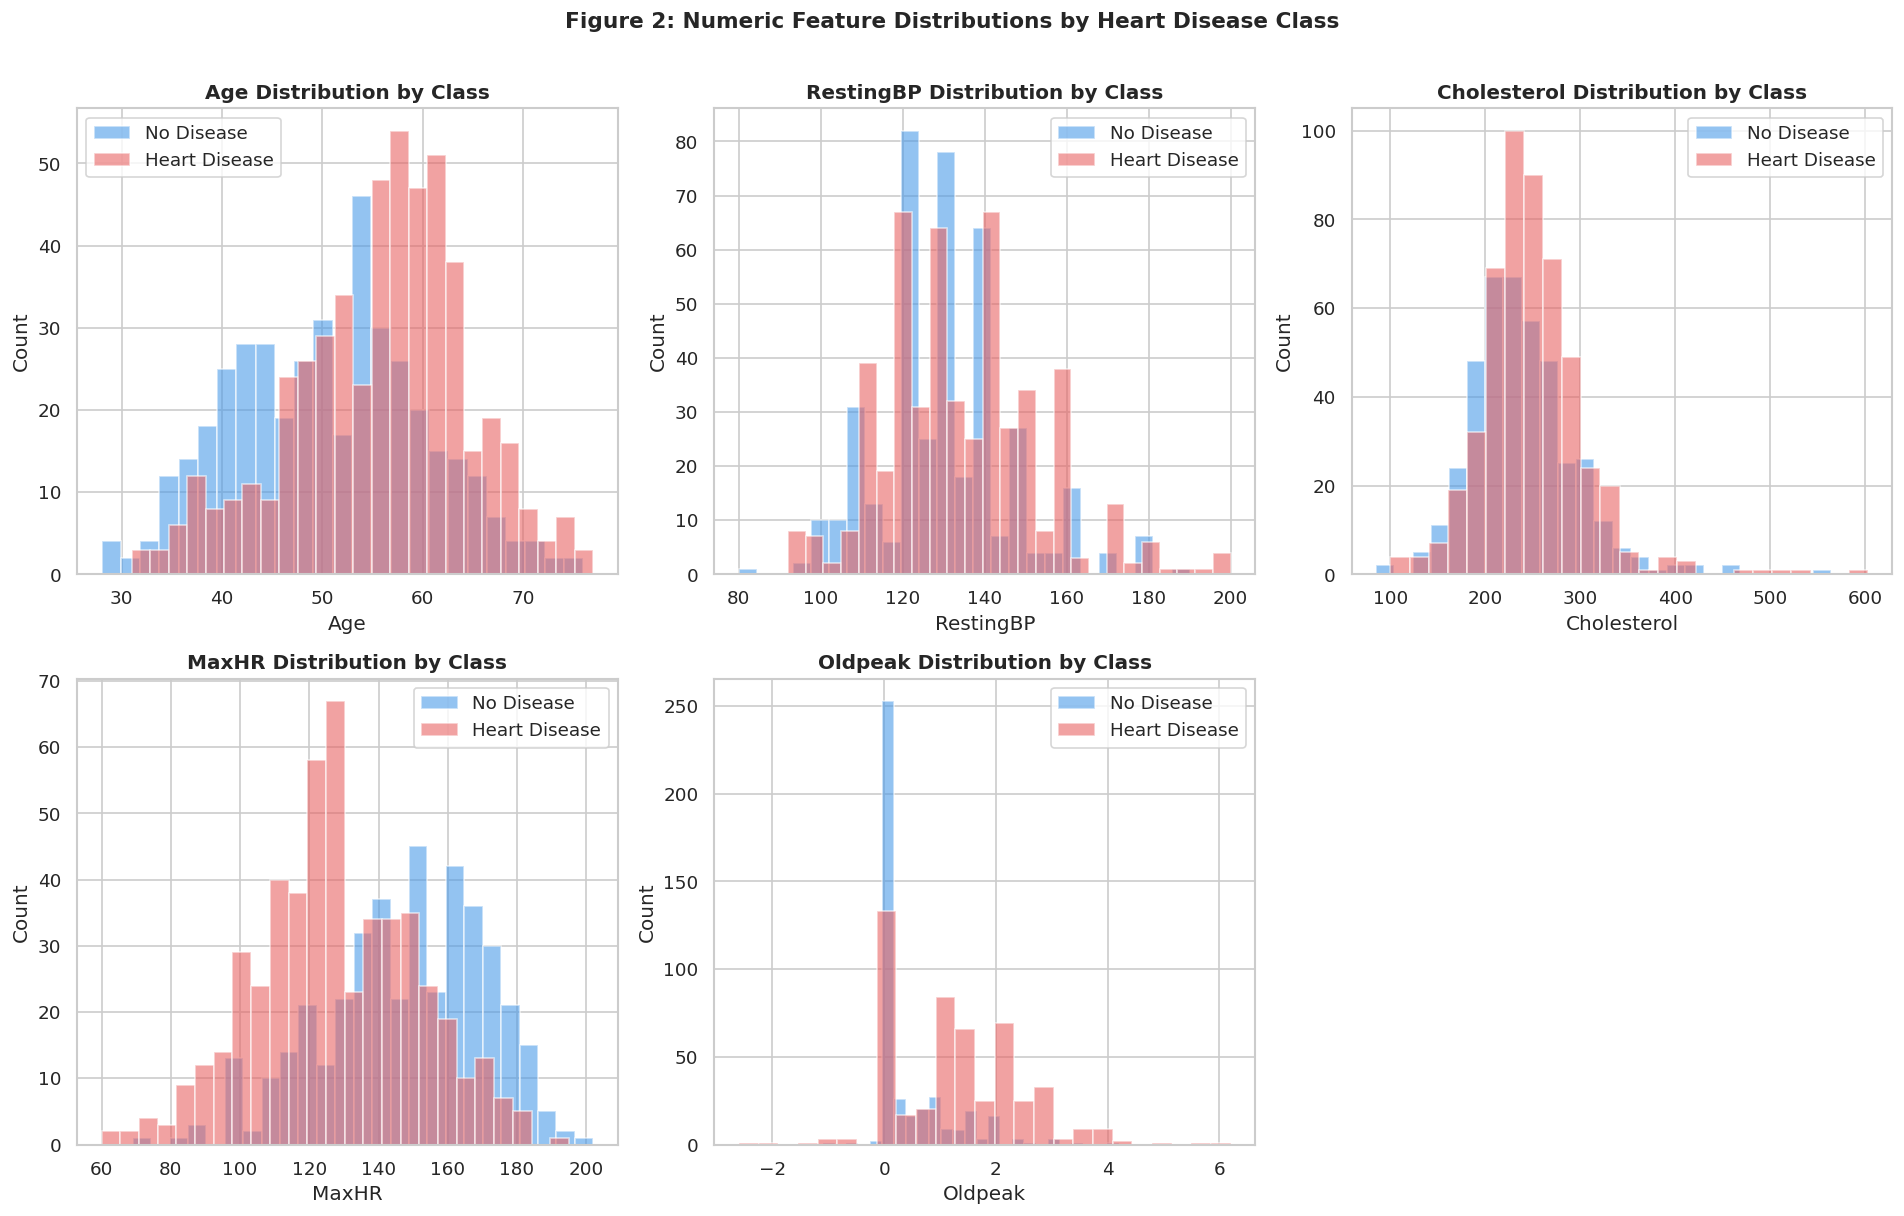

In [10]:
# =====================================================================
# 9. NUMERIC FEATURE DISTRIBUTIONS BY CLASS
# =====================================================================
numeric_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
labels = {0: 'No Disease', 1: 'Heart Disease'}
colors = {0: '#4c9be8', 1: '#e86464'}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for cls in [0, 1]:
        subset = df_clean[df_clean['HeartDisease'] == cls][col]
        axes[i].hist(subset, bins=25, alpha=0.6,
                     label=labels[cls], color=colors[cls], edgecolor='white')
    axes[i].set_title(f'{col} Distribution by Class', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

# Hide the last unused subplot
axes[5].set_visible(False)

plt.suptitle('Figure 2: Numeric Feature Distributions by Heart Disease Class',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig2_numeric_distributions.png', bbox_inches='tight')
plt.show()


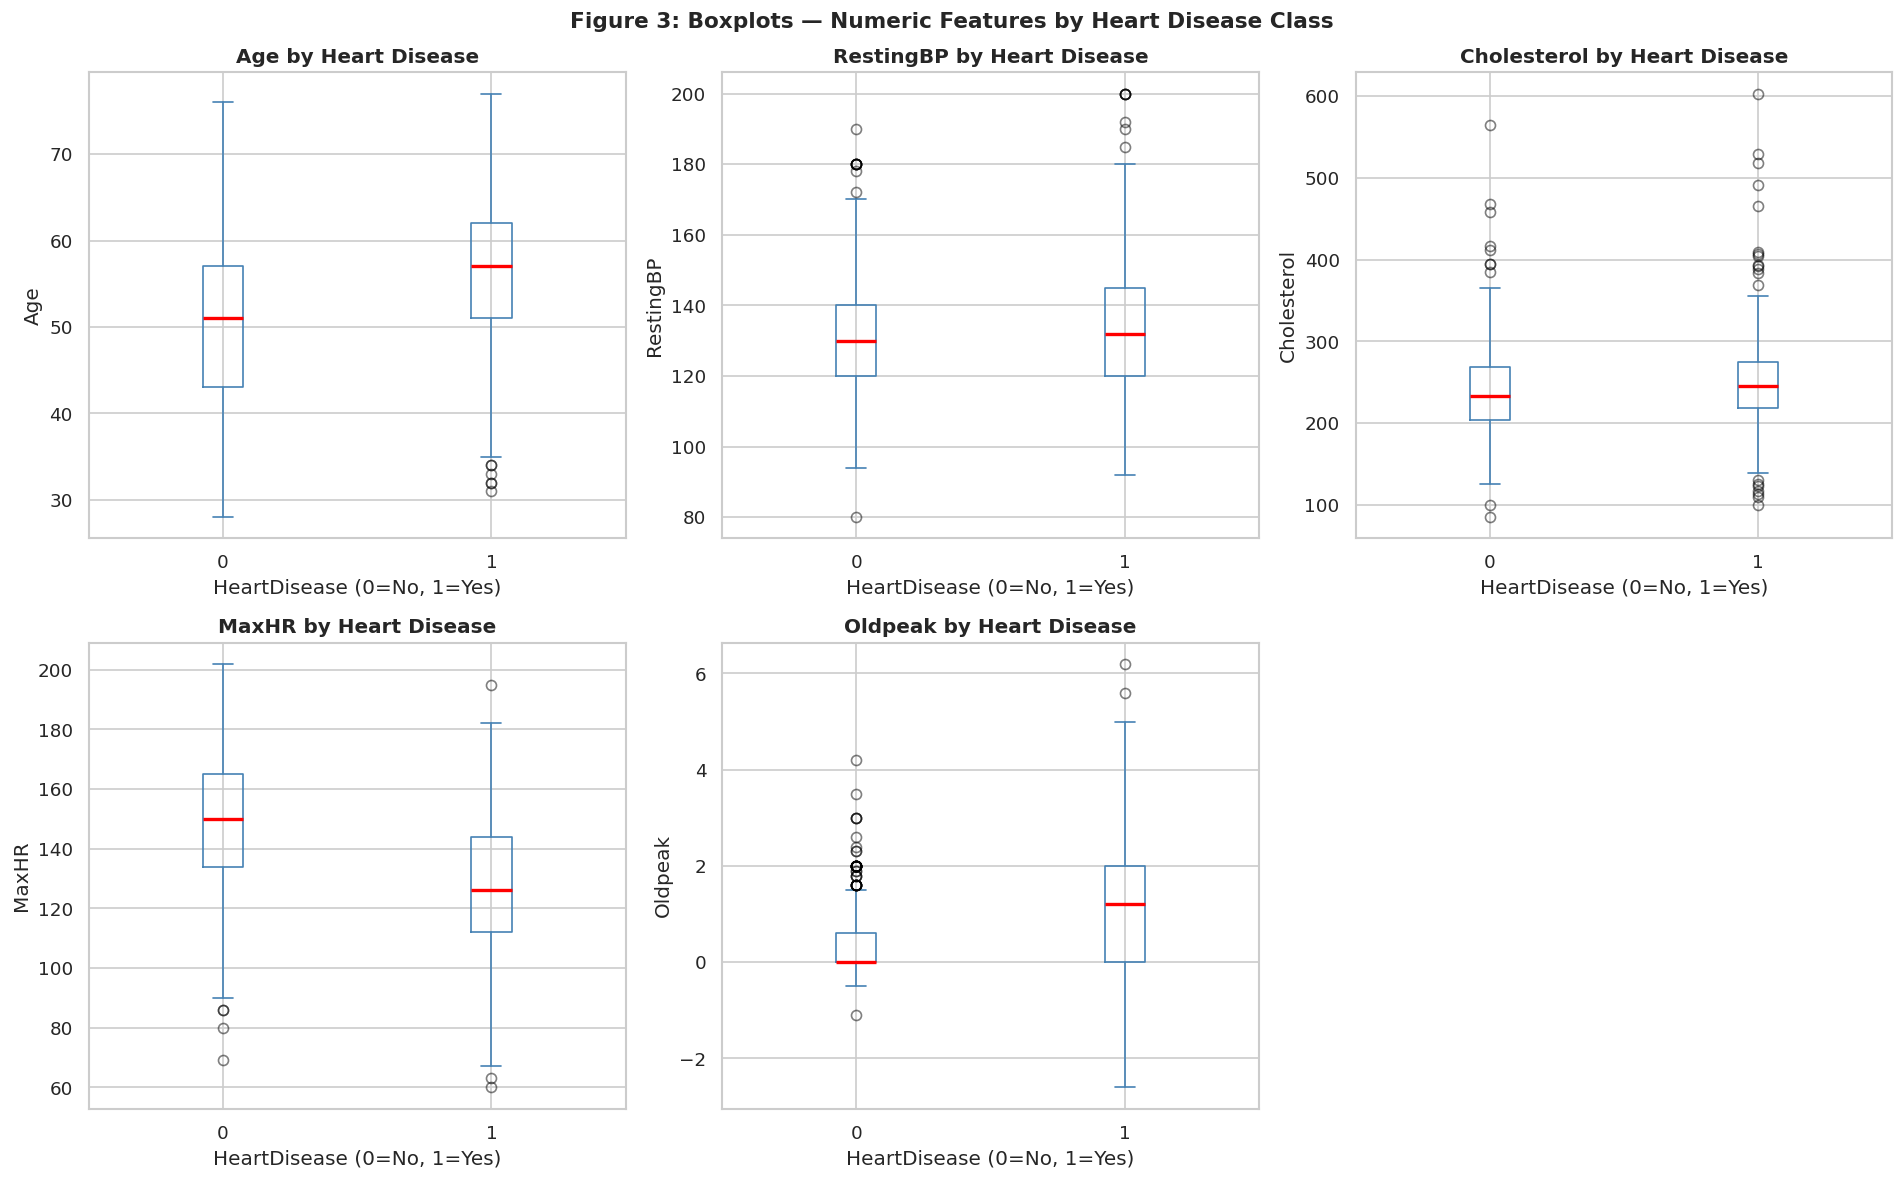

In [11]:
# =====================================================================
# 10. BOXPLOTS
# =====================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df_clean.boxplot(column=col, by='HeartDisease', ax=axes[i],
                     boxprops=dict(color='steelblue'),
                     medianprops=dict(color='red', linewidth=2),
                     whiskerprops=dict(color='steelblue'),
                     capprops=dict(color='steelblue'),
                     flierprops=dict(marker='o', color='orange', alpha=0.5))
    axes[i].set_title(f'{col} by Heart Disease', fontweight='bold')
    axes[i].set_xlabel('HeartDisease (0=No, 1=Yes)')
    axes[i].set_ylabel(col)

axes[5].set_visible(False)
plt.suptitle('Figure 3: Boxplots — Numeric Features by Heart Disease Class',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_boxplots.png', bbox_inches='tight')
plt.show()

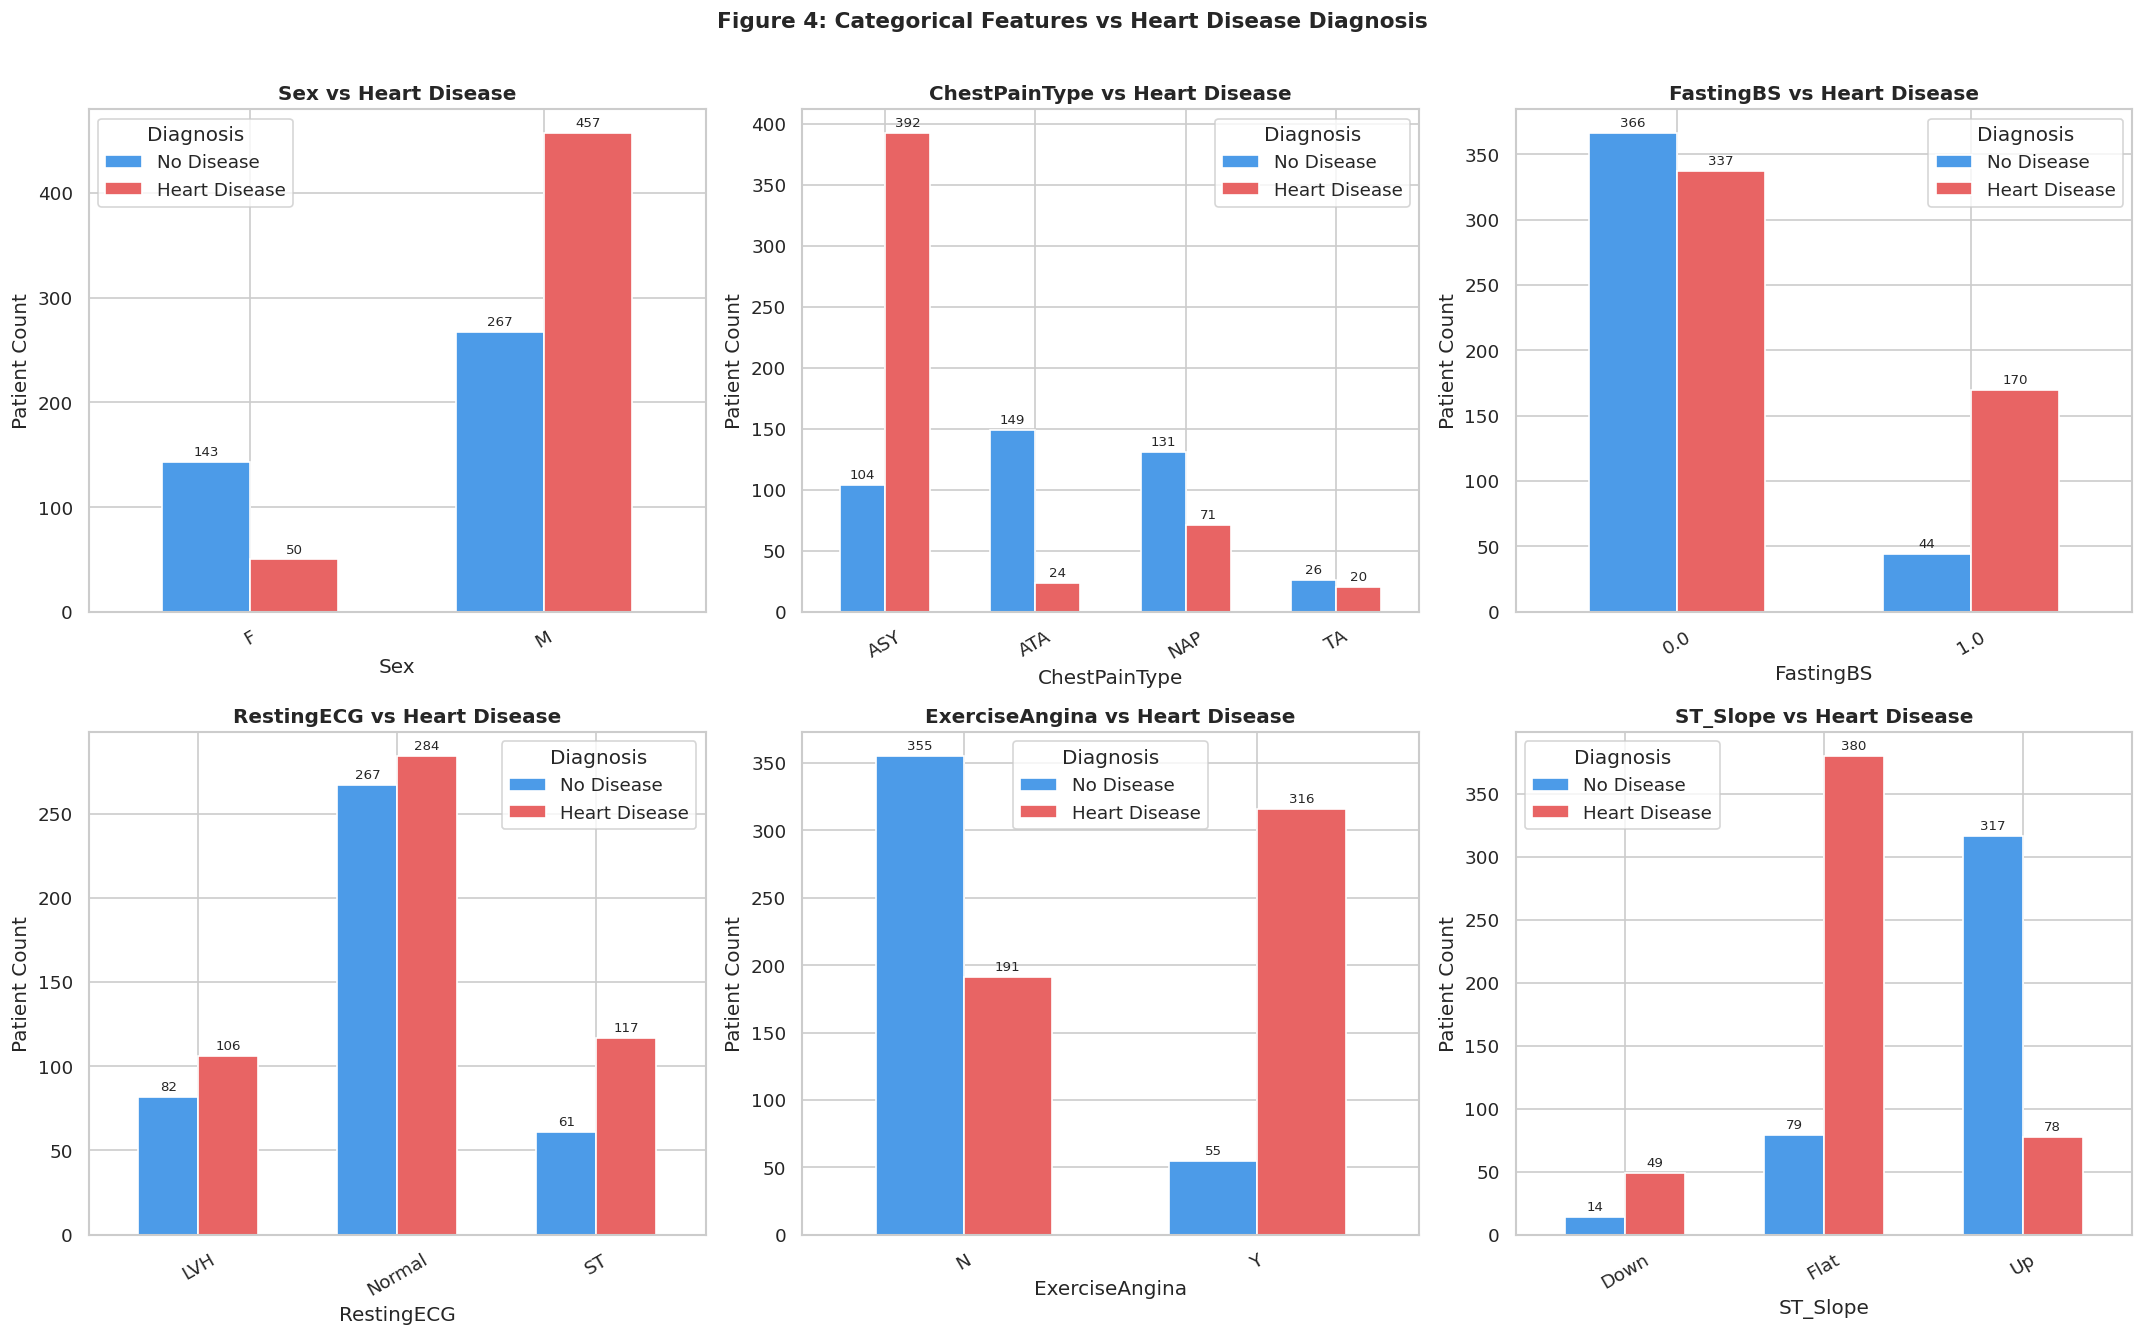

In [12]:
# =====================================================================
# 11. CATEGORICAL FEATURE ANALYSIS
# =====================================================================
cat_cols = ['Sex', 'ChestPainType', 'FastingBS',
            'RestingECG', 'ExerciseAngina', 'ST_Slope']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df_clean[col], df_clean['HeartDisease'])
    ct.columns = ['No Disease', 'Heart Disease']
    ct.plot(kind='bar', ax=axes[i], color=['#4c9be8', '#e86464'],
            edgecolor='white', width=0.6)
    axes[i].set_title(f'{col} vs Heart Disease', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Patient Count')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Diagnosis')
    # Add percentage labels on bars
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%d', padding=2, fontsize=8)

plt.suptitle('Figure 4: Categorical Features vs Heart Disease Diagnosis',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig4_categorical_analysis.png', bbox_inches='tight')
plt.show()


Age Group Risk Profile:
          Count  Disease Rate %
AgeGroup                       
<40          80         32.5000
40–49       211         40.3000
50–59       373         56.6000
60+         253         73.1000


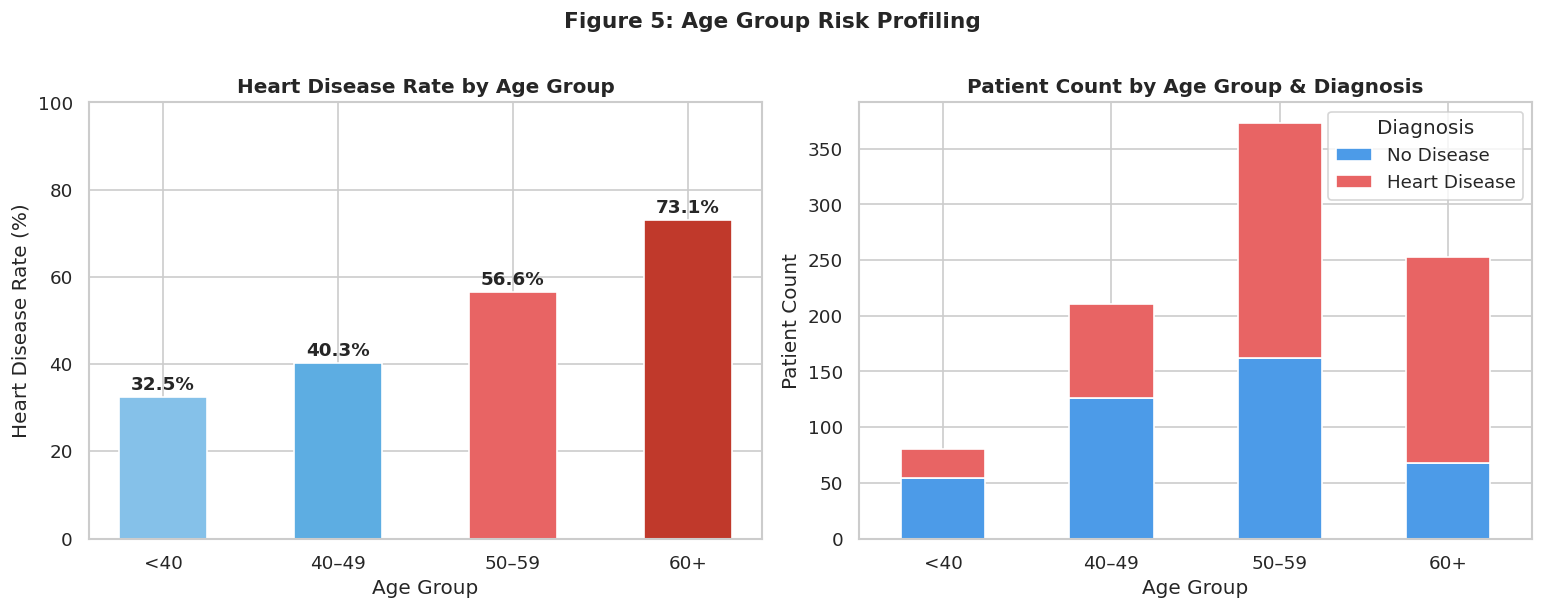

In [13]:
# =====================================================================
# 12. AGE GROUP RISK PROFILING (Extra Analysis)
# =====================================================================
df_clean['AgeGroup'] = pd.cut(df_clean['Age'],
                               bins=[0, 39, 49, 59, 100],
                               labels=['<40', '40–49', '50–59', '60+'])

age_risk = df_clean.groupby('AgeGroup', observed=True)['HeartDisease'].agg(['mean', 'count'])
age_risk.columns = ['Disease Rate', 'Count']
age_risk['Disease Rate %'] = (age_risk['Disease Rate'] * 100).round(1)

print("Age Group Risk Profile:")
print(age_risk[['Count', 'Disease Rate %']])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart — disease rate by age group
bars = axes[0].bar(age_risk.index,
                   age_risk['Disease Rate %'],
                   color=['#85c1e9', '#5dade2', '#e86464', '#c0392b'],
                   edgecolor='white', width=0.5)
axes[0].set_title('Heart Disease Rate by Age Group', fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Heart Disease Rate (%)')
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, age_risk['Disease Rate %']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1.5,
                 f'{val}%', ha='center', fontweight='bold')

# Stacked bar — count by group
counts_grouped = df_clean.groupby(['AgeGroup', 'HeartDisease'],
                                   observed=True).size().unstack()
counts_grouped.columns = ['No Disease', 'Heart Disease']
counts_grouped.plot(kind='bar', stacked=True, ax=axes[1],
                    color=['#4c9be8', '#e86464'], edgecolor='white', width=0.5)
axes[1].set_title('Patient Count by Age Group & Diagnosis', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Patient Count')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Diagnosis')

plt.suptitle('Figure 5: Age Group Risk Profiling',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig5_age_group_risk.png', bbox_inches='tight')
plt.show()


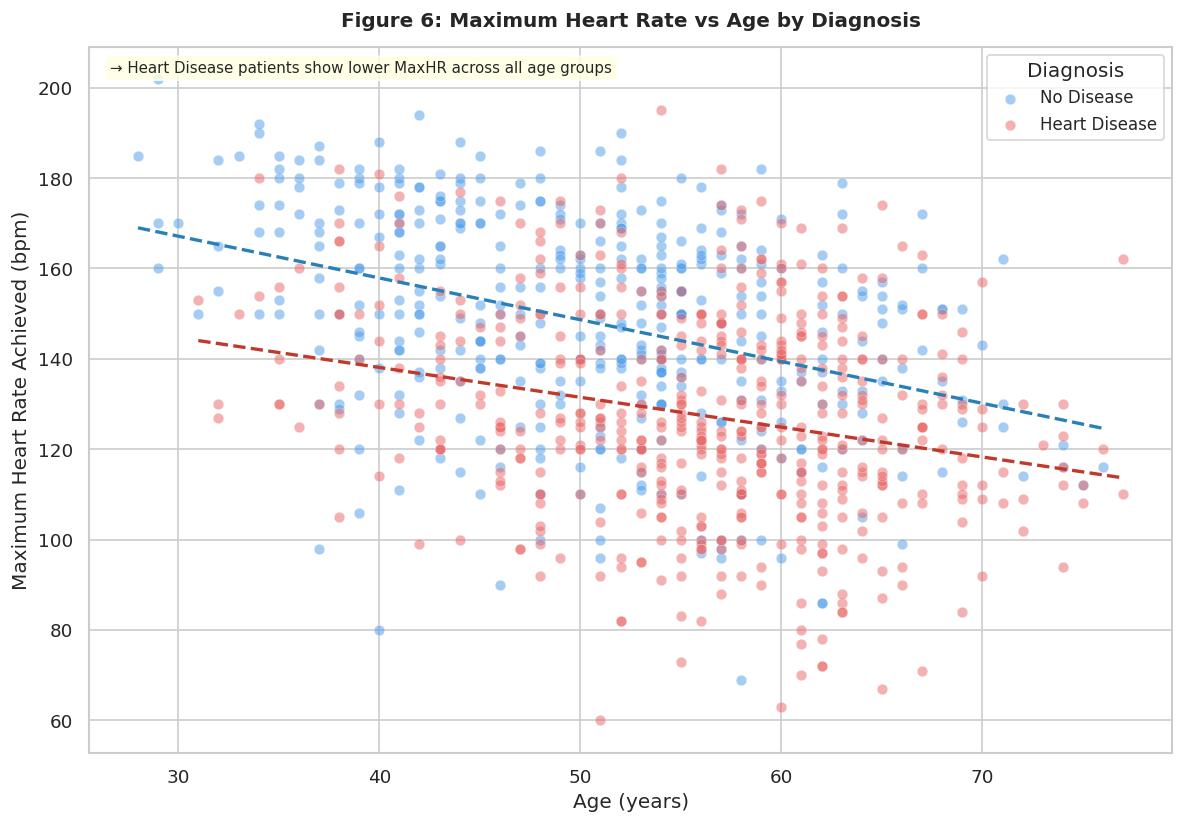

In [14]:
# =====================================================================
# 13. MaxHR VS AGE SCATTER (Extra Analysis)
# =====================================================================
fig, ax = plt.subplots(figsize=(10, 7))

for cls, label, color in [(0, 'No Disease', '#4c9be8'), (1, 'Heart Disease', '#e86464')]:
    subset = df_clean[df_clean['HeartDisease'] == cls]
    ax.scatter(subset['Age'], subset['MaxHR'],
               alpha=0.5, c=color, label=label, s=40, edgecolors='white', linewidths=0.3)

# Trend lines
for cls, color in [(0, '#2980b9'), (1, '#c0392b')]:
    subset = df_clean[df_clean['HeartDisease'] == cls]
    z = np.polyfit(subset['Age'], subset['MaxHR'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(subset['Age'].min(), subset['Age'].max(), 100)
    ax.plot(x_line, p(x_line), color=color, linewidth=2, linestyle='--')

ax.set_title('Figure 6: Maximum Heart Rate vs Age by Diagnosis',
             fontweight='bold', pad=12)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Maximum Heart Rate Achieved (bpm)')
ax.legend(title='Diagnosis', fontsize=10)
ax.text(0.02, 0.98,
        '→ Heart Disease patients show lower MaxHR across all age groups',
        transform=ax.transAxes, fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('fig6_maxhr_vs_age.png', bbox_inches='tight')
plt.show()


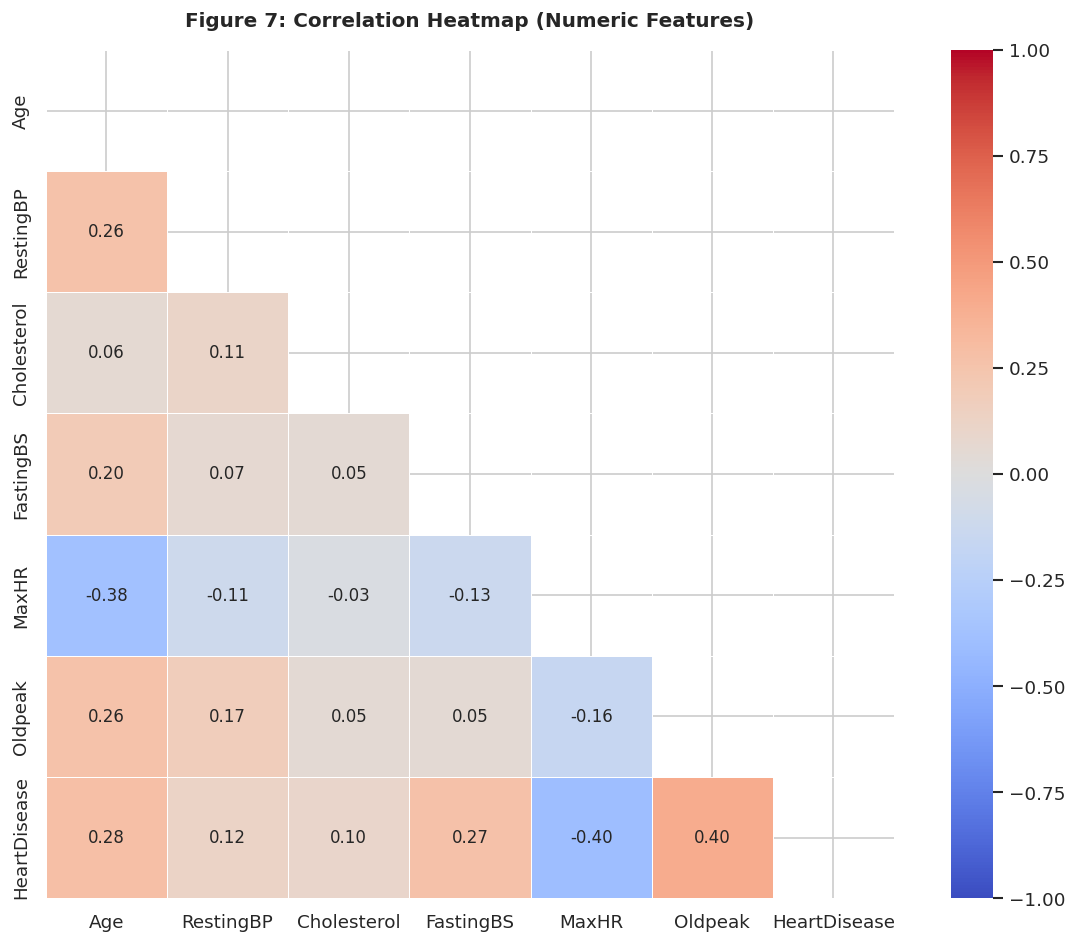

→ Note: Heatmap covers numeric features only.
  Nominal features (Sex, ChestPainType, etc.) are analysed separately via bar charts.


In [15]:
# =====================================================================
# 14. CORRELATION HEATMAP (NUMERIC FEATURES)
# =====================================================================
fig, ax = plt.subplots(figsize=(10, 8))
numeric_df = df_clean.select_dtypes(include=['float64', 'int64'])
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, mask=mask,
            square=True, linewidths=0.5, ax=ax,
            annot_kws={'size': 10})
ax.set_title('Figure 7: Correlation Heatmap (Numeric Features)',
             fontweight='bold', pad=14)

plt.tight_layout()
plt.savefig('fig7_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print("→ Note: Heatmap covers numeric features only.")
print("  Nominal features (Sex, ChestPainType, etc.) are analysed separately via bar charts.")


POINT-BISERIAL CORRELATION — Numeric Features vs Target
            Correlation p-value Significant
Oldpeak          0.4036  0.0000       ✅ Yes
MaxHR           -0.4014  0.0000       ✅ Yes
Age              0.2820  0.0000       ✅ Yes
RestingBP        0.1180  0.0003       ✅ Yes
Cholesterol      0.0953  0.0039       ✅ Yes


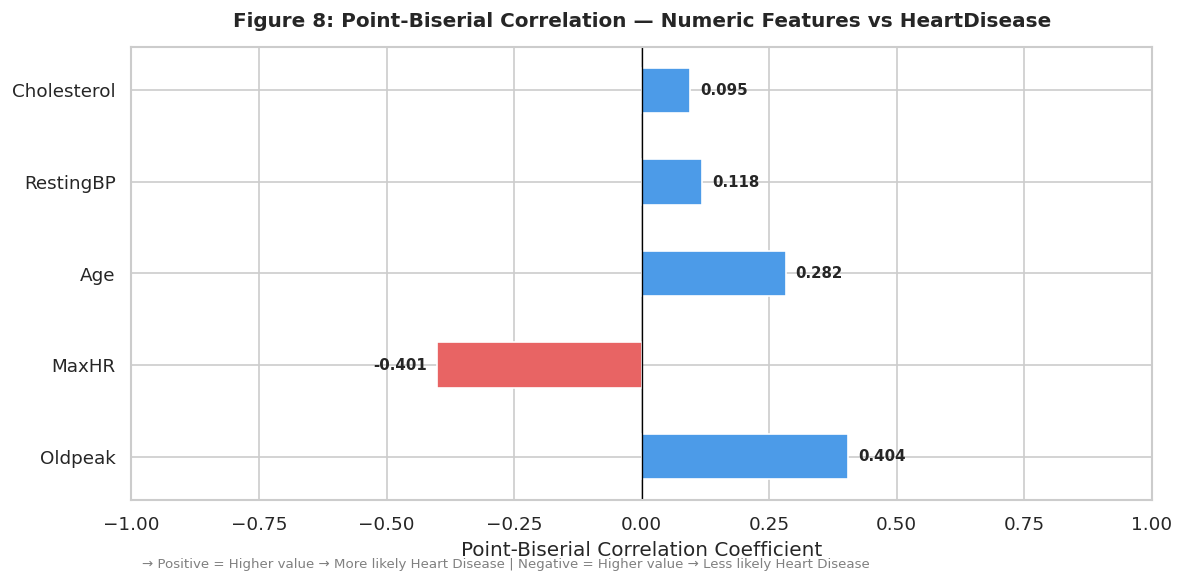

In [16]:
# =====================================================================
# 15. POINT-BISERIAL CORRELATION (Extra Analysis)
# =====================================================================
# Measures strength of association between each numeric feature
# and the binary target HeartDisease — this is the EXTRA computation

print("=" * 55)
print("POINT-BISERIAL CORRELATION — Numeric Features vs Target")
print("=" * 55)

pb_results = {}
for col in numeric_cols:
    corr, pval = pointbiserialr(df_clean['HeartDisease'], df_clean[col])
    pb_results[col] = {'Correlation': round(corr, 4), 'p-value': round(pval, 4),
                       'Significant': '✅ Yes' if pval < 0.05 else '❌ No'}

pb_df = pd.DataFrame(pb_results).T.sort_values('Correlation', key=abs, ascending=False)
print(pb_df.to_string())

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
colors_pb = ['#e86464' if v < 0 else '#4c9be8' for v in pb_df['Correlation'].astype(float)]
bars = ax.barh(pb_df.index, pb_df['Correlation'].astype(float),
               color=colors_pb, edgecolor='white', height=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Figure 8: Point-Biserial Correlation — Numeric Features vs HeartDisease',
             fontweight='bold', pad=12)
ax.set_xlabel('Point-Biserial Correlation Coefficient')
ax.set_xlim(-1, 1)
for bar, val in zip(bars, pb_df['Correlation'].astype(float)):
    offset = 0.02 if val >= 0 else -0.02
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', ha=ha, va='center', fontsize=9, fontweight='bold')
ax.text(0.01, -0.15,
        '→ Positive = Higher value → More likely Heart Disease | '
        'Negative = Higher value → Less likely Heart Disease',
        transform=ax.transAxes, fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('fig8_pointbiserial_correlation.png', bbox_inches='tight')
plt.show()

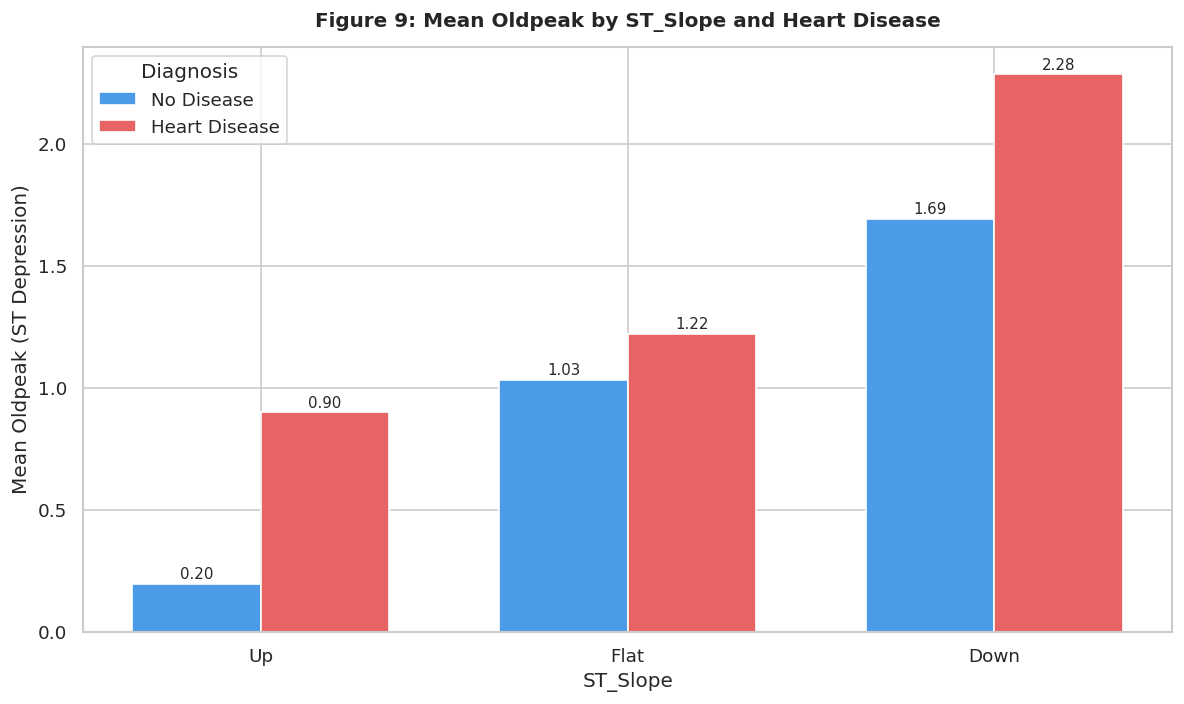

In [17]:
# =====================================================================
# 16. Oldpeak × ST_Slope ANALYSIS (Extra Analysis)
# =====================================================================
fig, ax = plt.subplots(figsize=(10, 6))
slope_order = ['Up', 'Flat', 'Down']
disease_means = df_clean.groupby(['ST_Slope', 'HeartDisease'],
                                  observed=True)['Oldpeak'].mean().unstack()
disease_means.columns = ['No Disease', 'Heart Disease']
disease_means = disease_means.reindex(slope_order)

x = np.arange(len(slope_order))
width = 0.35
bars1 = ax.bar(x - width/2, disease_means['No Disease'],
               width, label='No Disease', color='#4c9be8', edgecolor='white')
bars2 = ax.bar(x + width/2, disease_means['Heart Disease'],
               width, label='Heart Disease', color='#e86464', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(slope_order)
ax.set_title('Figure 9: Mean Oldpeak by ST_Slope and Heart Disease',
             fontweight='bold', pad=12)
ax.set_xlabel('ST_Slope')
ax.set_ylabel('Mean Oldpeak (ST Depression)')
ax.legend(title='Diagnosis')
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig9_oldpeak_st_slope.png', bbox_inches='tight')
plt.show()


In [18]:
# =====================================================================
# 17. FINAL SUMMARY STATISTICS
# =====================================================================
print("=" * 55)
print("EDA SUMMARY — KEY FINDINGS FOR REPORT")
print("=" * 55)

print(f"\n📊 Dataset: {df_clean.shape[0]} patients | {df_clean.shape[1]} features")
print(f"\n🎯 Class Distribution:")
vc = df_clean['HeartDisease'].value_counts()
print(f"   Heart Disease (1): {vc[1]} ({vc[1]/len(df_clean)*100:.1f}%)")
print(f"   No Disease    (0): {vc[0]} ({vc[0]/len(df_clean)*100:.1f}%)")
print(f"   → Mild imbalance (53/47 split)")
print(f"\n📈 Top Predictors (Point-Biserial Correlation with target):")
for col, row in pb_df.iterrows():
    print(f"   {col:20s}: r = {float(row['Correlation']):+.3f}  {row['Significant']}")

print(f"\n👥 Age Group Risk (% with Heart Disease):")
for group, row in age_risk.iterrows():
    print(f"   {group}: {row['Disease Rate %']}%  (n={int(row['Count'])})")

print(f"\n✅ Figures saved:")
figures = [
    "fig1_class_distribution.png",
    "fig2_numeric_distributions.png",
    "fig3_boxplots.png",
    "fig4_categorical_analysis.png",
    "fig5_age_group_risk.png",
    "fig6_maxhr_vs_age.png",
    "fig7_correlation_heatmap.png",
    "fig8_pointbiserial_correlation.png",
    "fig9_oldpeak_st_slope.png"
]
for f in figures:
    print(f"   • {f}")

EDA SUMMARY — KEY FINDINGS FOR REPORT

📊 Dataset: 917 patients | 13 features

🎯 Class Distribution:
   Heart Disease (1): 507 (55.3%)
   No Disease    (0): 410 (44.7%)
   → Mild imbalance (53/47 split)

📈 Top Predictors (Point-Biserial Correlation with target):
   Oldpeak             : r = +0.404  ✅ Yes
   MaxHR               : r = -0.401  ✅ Yes
   Age                 : r = +0.282  ✅ Yes
   RestingBP           : r = +0.118  ✅ Yes
   Cholesterol         : r = +0.095  ✅ Yes

👥 Age Group Risk (% with Heart Disease):
   <40: 32.5%  (n=80)
   40–49: 40.3%  (n=211)
   50–59: 56.6%  (n=373)
   60+: 73.1%  (n=253)

✅ Figures saved:
   • fig1_class_distribution.png
   • fig2_numeric_distributions.png
   • fig3_boxplots.png
   • fig4_categorical_analysis.png
   • fig5_age_group_risk.png
   • fig6_maxhr_vs_age.png
   • fig7_correlation_heatmap.png
   • fig8_pointbiserial_correlation.png
   • fig9_oldpeak_st_slope.png


In [19]:
# ── CELL 16: Save Clean Dataset ───────────────────────────
df_clean.drop(columns=['AgeGroup'], inplace=True)
df_clean.to_csv('heart_clean.csv', index=False)
print("\n✅ Clean dataset saved as 'heart_clean.csv'")



✅ Clean dataset saved as 'heart_clean.csv'


In [20]:
# =====================================================================
# 18. FEATURE ENCODING AND SCALING
# =====================================================================

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

# Separate features and target
X = df_encoded.drop(columns=['HeartDisease'])
y = df_encoded['HeartDisease']

# Standardize numeric features (required for SVM, Logistic Regression, MLP)
scaler = StandardScaler()

print(f"\nFeature matrix: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Features: {list(X.columns)}")


Feature matrix: 917 samples, 15 features
Features: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'FastingBS_1.0', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


In [21]:
# =====================================================================
# 19. BASELINE MODEL DEFINITIONS
# =====================================================================
# Six classification models selected for diversity:
# - Logistic Regression: linear baseline, interpretable coefficients
# - Random Forest: ensemble of decision trees, handles non-linearity
# - Gradient Boosting: sequential ensemble, strong predictive power
# - Support Vector Machine: kernel-based, effective in high dimensions
# - Multilayer Perceptron: neural network, captures complex patterns
# - Gaussian Naive Bayes: probabilistic model, well-calibrated posteriors

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ]),
    'Random Forest': RandomForestClassifier(
        random_state=RANDOM_STATE
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE))
    ]),
    'MLP Neural Network': Pipeline([
        ('scaler', StandardScaler()),
        ('model', MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                                solver='adam', max_iter=500,
                                random_state=RANDOM_STATE,
                                early_stopping=True, validation_fraction=0.1))
    ]),
    'Naive Bayes': GaussianNB()
}

print("✅ Models defined. LR, SVM, MLP wrapped in Pipeline (scaler fits per fold only).")
print("   RF, GB, Naive Bayes need no scaling — used directly.")

✅ Models defined. LR, SVM, MLP wrapped in Pipeline (scaler fits per fold only).
   RF, GB, Naive Bayes need no scaling — used directly.


In [22]:
# =====================================================================
# 20. BASELINE EVALUATION — 10-Fold Stratified Cross-Validation
# =====================================================================
print(f"\n{'='*70}")
print("BASELINE MODEL EVALUATION — 10-Fold Stratified Cross-Validation")
print(f"{'='*70}\n")

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
baseline_results = {}

for name, model in models.items():
    acc_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    f1_scores = cross_val_score(model, X, y, cv=cv, scoring='f1')
    prec_scores = cross_val_score(model, X, y, cv=cv, scoring='precision')
    rec_scores = cross_val_score(model, X, y, cv=cv, scoring='recall')
    auc_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')

    baseline_results[name] = {
        'Accuracy': acc_scores, 'F1-Score': f1_scores,
        'Precision': prec_scores, 'Recall': rec_scores, 'AUC-ROC': auc_scores
    }

    print(f"{name}:")
    print(f"  Accuracy:  {acc_scores.mean():.4f} +/- {acc_scores.std():.4f}")
    print(f"  F1-Score:  {f1_scores.mean():.4f} +/- {f1_scores.std():.4f}")
    print(f"  Precision: {prec_scores.mean():.4f} +/- {prec_scores.std():.4f}")
    print(f"  Recall:    {rec_scores.mean():.4f} +/- {rec_scores.std():.4f}")
    print(f"  AUC-ROC:   {auc_scores.mean():.4f} +/- {auc_scores.std():.4f}")
    print()


BASELINE MODEL EVALUATION — 10-Fold Stratified Cross-Validation

Logistic Regression:
  Accuracy:  0.8615 +/- 0.0229
  F1-Score:  0.8768 +/- 0.0200
  Precision: 0.8644 +/- 0.0354
  Recall:    0.8917 +/- 0.0350
  AUC-ROC:   0.9206 +/- 0.0250

Random Forest:
  Accuracy:  0.8570 +/- 0.0354
  F1-Score:  0.8739 +/- 0.0289
  Precision: 0.8594 +/- 0.0549
  Recall:    0.8915 +/- 0.0295
  AUC-ROC:   0.9193 +/- 0.0295

Gradient Boosting:
  Accuracy:  0.8592 +/- 0.0325
  F1-Score:  0.8751 +/- 0.0258
  Precision: 0.8654 +/- 0.0519
  Recall:    0.8876 +/- 0.0275
  AUC-ROC:   0.9239 +/- 0.0228

SVM:
  Accuracy:  0.8603 +/- 0.0363
  F1-Score:  0.8782 +/- 0.0296
  Precision: 0.8536 +/- 0.0512
  Recall:    0.9074 +/- 0.0381
  AUC-ROC:   0.9193 +/- 0.0261

MLP Neural Network:
  Accuracy:  0.8441 +/- 0.0410
  F1-Score:  0.8609 +/- 0.0373
  Precision: 0.8511 +/- 0.0478
  Recall:    0.8740 +/- 0.0553
  AUC-ROC:   0.8989 +/- 0.0306

Naive Bayes:
  Accuracy:  0.8549 +/- 0.0300
  F1-Score:  0.8685 +/- 0.0263

In [23]:
# =====================================================================
# 21. HYPERPARAMETER TUNING — GridSearchCV (5-Fold Inner CV)
# =====================================================================
print(f"{'='*70}")
print("HYPERPARAMETER TUNING — GridSearchCV (5-Fold CV)")
print(f"{'='*70}\n")

param_grids = {
    'Logistic Regression': {
        'model__C': [0.01, 0.1, 1, 10],
        'model__solver': ['lbfgs', 'liblinear']
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, 15],
        'min_samples_leaf': [1, 2, 3]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 4, 5],
        'learning_rate': [0.05, 0.1, 0.2]
    },
    'SVM': {
        'model__C': [0.1, 1, 10],
        'model__kernel': ['rbf', 'linear'],
        'model__gamma': ['scale', 'auto']
    },
    'MLP Neural Network': {
        'model__hidden_layer_sizes': [(64, 32), (128, 64), (64, 32, 16)],
        'model__activation': ['relu', 'tanh'],
        'model__alpha': [0.0001, 0.001]
    },
    'Naive Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
    }
}

tuned_models = {}
best_params_all = {}

for name, model in models.items():
    grid = GridSearchCV(
        model, param_grids[name],
        cv=5, scoring='f1',
        n_jobs=-1, refit=True
    )
    grid.fit(X, y)
    tuned_models[name] = grid.best_estimator_
    best_params_all[name] = grid.best_params_

    print(f"{name}:")
    print(f"  Best params: {grid.best_params_}")
    print(f"  Best CV F1:  {grid.best_score_:.4f}")
    print()



HYPERPARAMETER TUNING — GridSearchCV (5-Fold CV)

Logistic Regression:
  Best params: {'model__C': 0.01, 'model__solver': 'lbfgs'}
  Best CV F1:  0.8564

Random Forest:
  Best params: {'max_depth': 15, 'min_samples_leaf': 2, 'n_estimators': 100}
  Best CV F1:  0.8545

Gradient Boosting:
  Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
  Best CV F1:  0.8470

SVM:
  Best params: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
  Best CV F1:  0.8557

MLP Neural Network:
  Best params: {'model__activation': 'relu', 'model__alpha': 0.0001, 'model__hidden_layer_sizes': (128, 64)}
  Best CV F1:  0.8566

Naive Bayes:
  Best params: {'var_smoothing': 1e-05}
  Best CV F1:  0.8506



In [24]:
# =====================================================================
# 22. TUNED MODEL EVALUATION — 10-Fold Stratified Cross-Validation
# =====================================================================
print(f"{'='*70}")
print("TUNED MODEL EVALUATION — 10-Fold Stratified Cross-Validation")
print(f"{'='*70}\n")

tuned_results = {}

for name, model in tuned_models.items():
    acc_scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    f1_scores = cross_val_score(model, X, y, cv=cv, scoring='f1')
    prec_scores = cross_val_score(model, X, y, cv=cv, scoring='precision')
    rec_scores = cross_val_score(model, X, y, cv=cv, scoring='recall')
    auc_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')

    tuned_results[name] = {
        'Accuracy': acc_scores, 'F1-Score': f1_scores,
        'Precision': prec_scores, 'Recall': rec_scores, 'AUC-ROC': auc_scores
    }

    print(f"{name}:")
    print(f"  Accuracy:  {acc_scores.mean():.4f} +/- {acc_scores.std():.4f}")
    print(f"  F1-Score:  {f1_scores.mean():.4f} +/- {f1_scores.std():.4f}")
    print(f"  Precision: {prec_scores.mean():.4f} +/- {prec_scores.std():.4f}")
    print(f"  Recall:    {rec_scores.mean():.4f} +/- {rec_scores.std():.4f}")
    print(f"  AUC-ROC:   {auc_scores.mean():.4f} +/- {auc_scores.std():.4f}")
    print()

TUNED MODEL EVALUATION — 10-Fold Stratified Cross-Validation

Logistic Regression:
  Accuracy:  0.8636 +/- 0.0252
  F1-Score:  0.8795 +/- 0.0214
  Precision: 0.8628 +/- 0.0404
  Recall:    0.8996 +/- 0.0374
  AUC-ROC:   0.9222 +/- 0.0256

Random Forest:
  Accuracy:  0.8647 +/- 0.0271
  F1-Score:  0.8806 +/- 0.0216
  Precision: 0.8648 +/- 0.0456
  Recall:    0.8995 +/- 0.0296
  AUC-ROC:   0.9220 +/- 0.0287

Gradient Boosting:
  Accuracy:  0.8658 +/- 0.0343
  F1-Score:  0.8815 +/- 0.0274
  Precision: 0.8666 +/- 0.0486
  Recall:    0.8995 +/- 0.0320
  AUC-ROC:   0.9262 +/- 0.0218

SVM:
  Accuracy:  0.8626 +/- 0.0291
  F1-Score:  0.8779 +/- 0.0254
  Precision: 0.8650 +/- 0.0409
  Recall:    0.8937 +/- 0.0400
  AUC-ROC:   0.9195 +/- 0.0251

MLP Neural Network:
  Accuracy:  0.8549 +/- 0.0321
  F1-Score:  0.8723 +/- 0.0254
  Precision: 0.8560 +/- 0.0534
  Recall:    0.8936 +/- 0.0430
  AUC-ROC:   0.9144 +/- 0.0270

Naive Bayes:
  Accuracy:  0.8593 +/- 0.0265
  F1-Score:  0.8740 +/- 0.0241
  P

In [25]:
# =====================================================================
# 23. PERFORMANCE SUMMARY — Baseline vs Tuned
# =====================================================================
print(f"{'='*70}")
print("PERFORMANCE SUMMARY — Baseline vs Tuned")
print(f"{'='*70}\n")

model_names = list(models.keys())

print(f"{'Model':<22}{'Baseline Acc':<15}{'Tuned Acc':<15}{'Baseline F1':<15}{'Tuned F1':<15}{'Improvement':<12}")
print("-" * 94)

for name in model_names:
    b_acc = baseline_results[name]['Accuracy'].mean()
    t_acc = tuned_results[name]['Accuracy'].mean()
    b_f1 = baseline_results[name]['F1-Score'].mean()
    t_f1 = tuned_results[name]['F1-Score'].mean()
    imp = t_f1 - b_f1
    arrow = "+" if imp > 0 else ""
    print(f"{name:<22}{b_acc:<15.4f}{t_acc:<15.4f}{b_f1:<15.4f}{t_f1:<15.4f}{arrow}{imp:.4f}")



PERFORMANCE SUMMARY — Baseline vs Tuned

Model                 Baseline Acc   Tuned Acc      Baseline F1    Tuned F1       Improvement 
----------------------------------------------------------------------------------------------
Logistic Regression   0.8615         0.8636         0.8768         0.8795         +0.0027
Random Forest         0.8570         0.8647         0.8739         0.8806         +0.0067
Gradient Boosting     0.8592         0.8658         0.8751         0.8815         +0.0064
SVM                   0.8603         0.8626         0.8782         0.8779         -0.0003
MLP Neural Network    0.8441         0.8549         0.8609         0.8723         +0.0114
Naive Bayes           0.8549         0.8593         0.8685         0.8740         +0.0055


In [26]:
# =====================================================================
# 24. OVERFITTING ANALYSIS
# =====================================================================
print(f"\n{'='*70}")
print("OVERFITTING ANALYSIS — Training vs Cross-Validation Accuracy")
print(f"{'='*70}\n")

print(f"{'Model':<22}{'Train Acc':<14}{'CV Acc':<14}{'Gap':<12}{'Status':<15}")
print("-" * 72)

overfit_data = {}
for name, model in tuned_models.items():
    model.fit(X, y)
    train_acc = model.score(X, y) * 100
    cv_acc = tuned_results[name]['Accuracy'].mean() * 100
    gap = train_acc - cv_acc
    overfit_data[name] = {'train': train_acc, 'cv': cv_acc, 'gap': gap}

    if abs(gap) < 5:
        status = "Good"
    elif abs(gap) < 10:
        status = "Mild overfit"
    else:
        status = "Overfitting"

    print(f"{name:<22}{train_acc:<14.2f}{cv_acc:<14.2f}{gap:<+12.2f}{status:<15}")




OVERFITTING ANALYSIS — Training vs Cross-Validation Accuracy

Model                 Train Acc     CV Acc        Gap         Status         
------------------------------------------------------------------------
Logistic Regression   86.59         86.36         +0.22       Good           
Random Forest         95.09         86.47         +8.62       Mild overfit   
Gradient Boosting     91.38         86.58         +4.80       Good           
SVM                   86.70         86.26         +0.44       Good           
MLP Neural Network    87.02         85.49         +1.54       Good           
Naive Bayes           86.04         85.93         +0.11       Good           


In [27]:
# =====================================================================
# 25. STATISTICAL SIGNIFICANCE — Paired t-test Between Models
# =====================================================================
print(f"\n{'='*70}")
print("STATISTICAL SIGNIFICANCE — Paired t-test (Accuracy, 10-fold CV)")
print(f"{'='*70}\n")

print(f"{'Model A':<25}{'Model B':<25}{'t-stat':<10}{'p-value':<10}{'Significant?':<12}")
print("-" * 82)

for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        a = tuned_results[model_names[i]]['Accuracy']
        b = tuned_results[model_names[j]]['Accuracy']
        t_stat, p_val = stats.ttest_rel(a, b)
        sig = "Yes (p<0.05)" if p_val < 0.05 else "No"
        print(f"{model_names[i]:<25}{model_names[j]:<25}{t_stat:<10.4f}{p_val:<10.4f}{sig:<12}")



STATISTICAL SIGNIFICANCE — Paired t-test (Accuracy, 10-fold CV)

Model A                  Model B                  t-stat    p-value   Significant?
----------------------------------------------------------------------------------
Logistic Regression      Random Forest            -0.1873   0.8556    No          
Logistic Regression      Gradient Boosting        -0.3750   0.7163    No          
Logistic Regression      SVM                      0.4267    0.6797    No          
Logistic Regression      MLP Neural Network       1.2411    0.2459    No          
Logistic Regression      Naive Bayes              1.0776    0.3092    No          
Random Forest            Gradient Boosting        -0.1778   0.8628    No          
Random Forest            SVM                      0.4053    0.6947    No          
Random Forest            MLP Neural Network       0.9746    0.3552    No          
Random Forest            Naive Bayes              0.7078    0.4970    No          
Gradient Boosting    

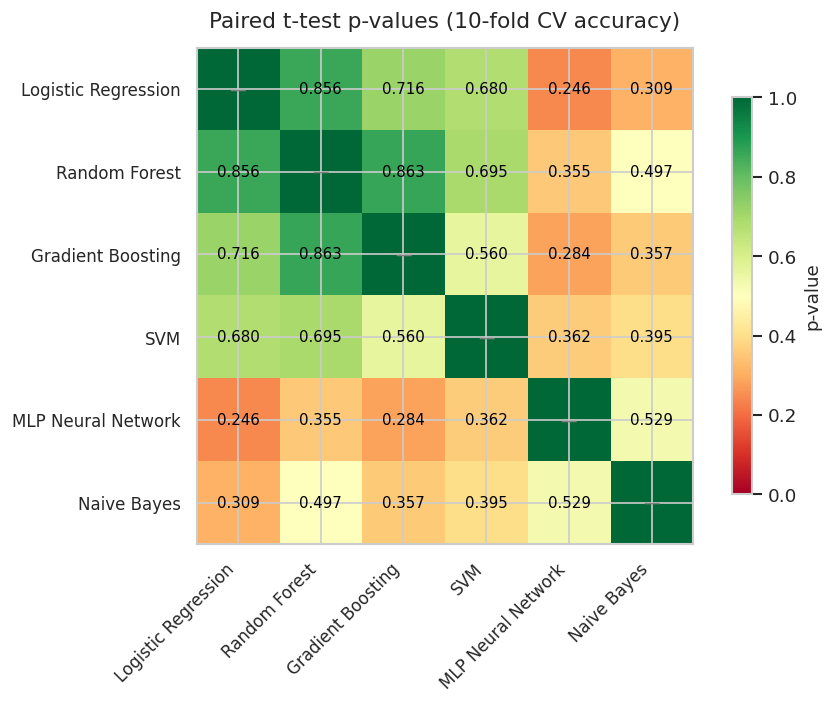

In [28]:
# =====================================================================
# 25b. HEATMAP — Paired t-test p-values
# =====================================================================
import numpy as np
import matplotlib.pyplot as plt

n = len(model_names)
p_matrix = np.ones((n, n))

for i in range(n):
    for j in range(i+1, n):
        a = tuned_results[model_names[i]]['Accuracy']
        b = tuned_results[model_names[j]]['Accuracy']
        _, p_val = stats.ttest_rel(a, b)
        p_matrix[i, j] = p_val
        p_matrix[j, i] = p_val

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(p_matrix, cmap='RdYlGn', vmin=0, vmax=1)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(model_names, fontsize=10)

for i in range(n):
    for j in range(n):
        if i != j:
            ax.text(j, i, f'{p_matrix[i,j]:.3f}', ha='center', va='center',
                    fontsize=9, fontweight='bold' if p_matrix[i,j] < 0.05 else 'normal',
                    color='white' if p_matrix[i,j] < 0.15 else 'black')
        else:
            ax.text(j, i, '—', ha='center', va='center', fontsize=10, color='grey')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('p-value', fontsize=11)

ax.set_title('Paired t-test p-values (10-fold CV accuracy)', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('fig_ttest_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

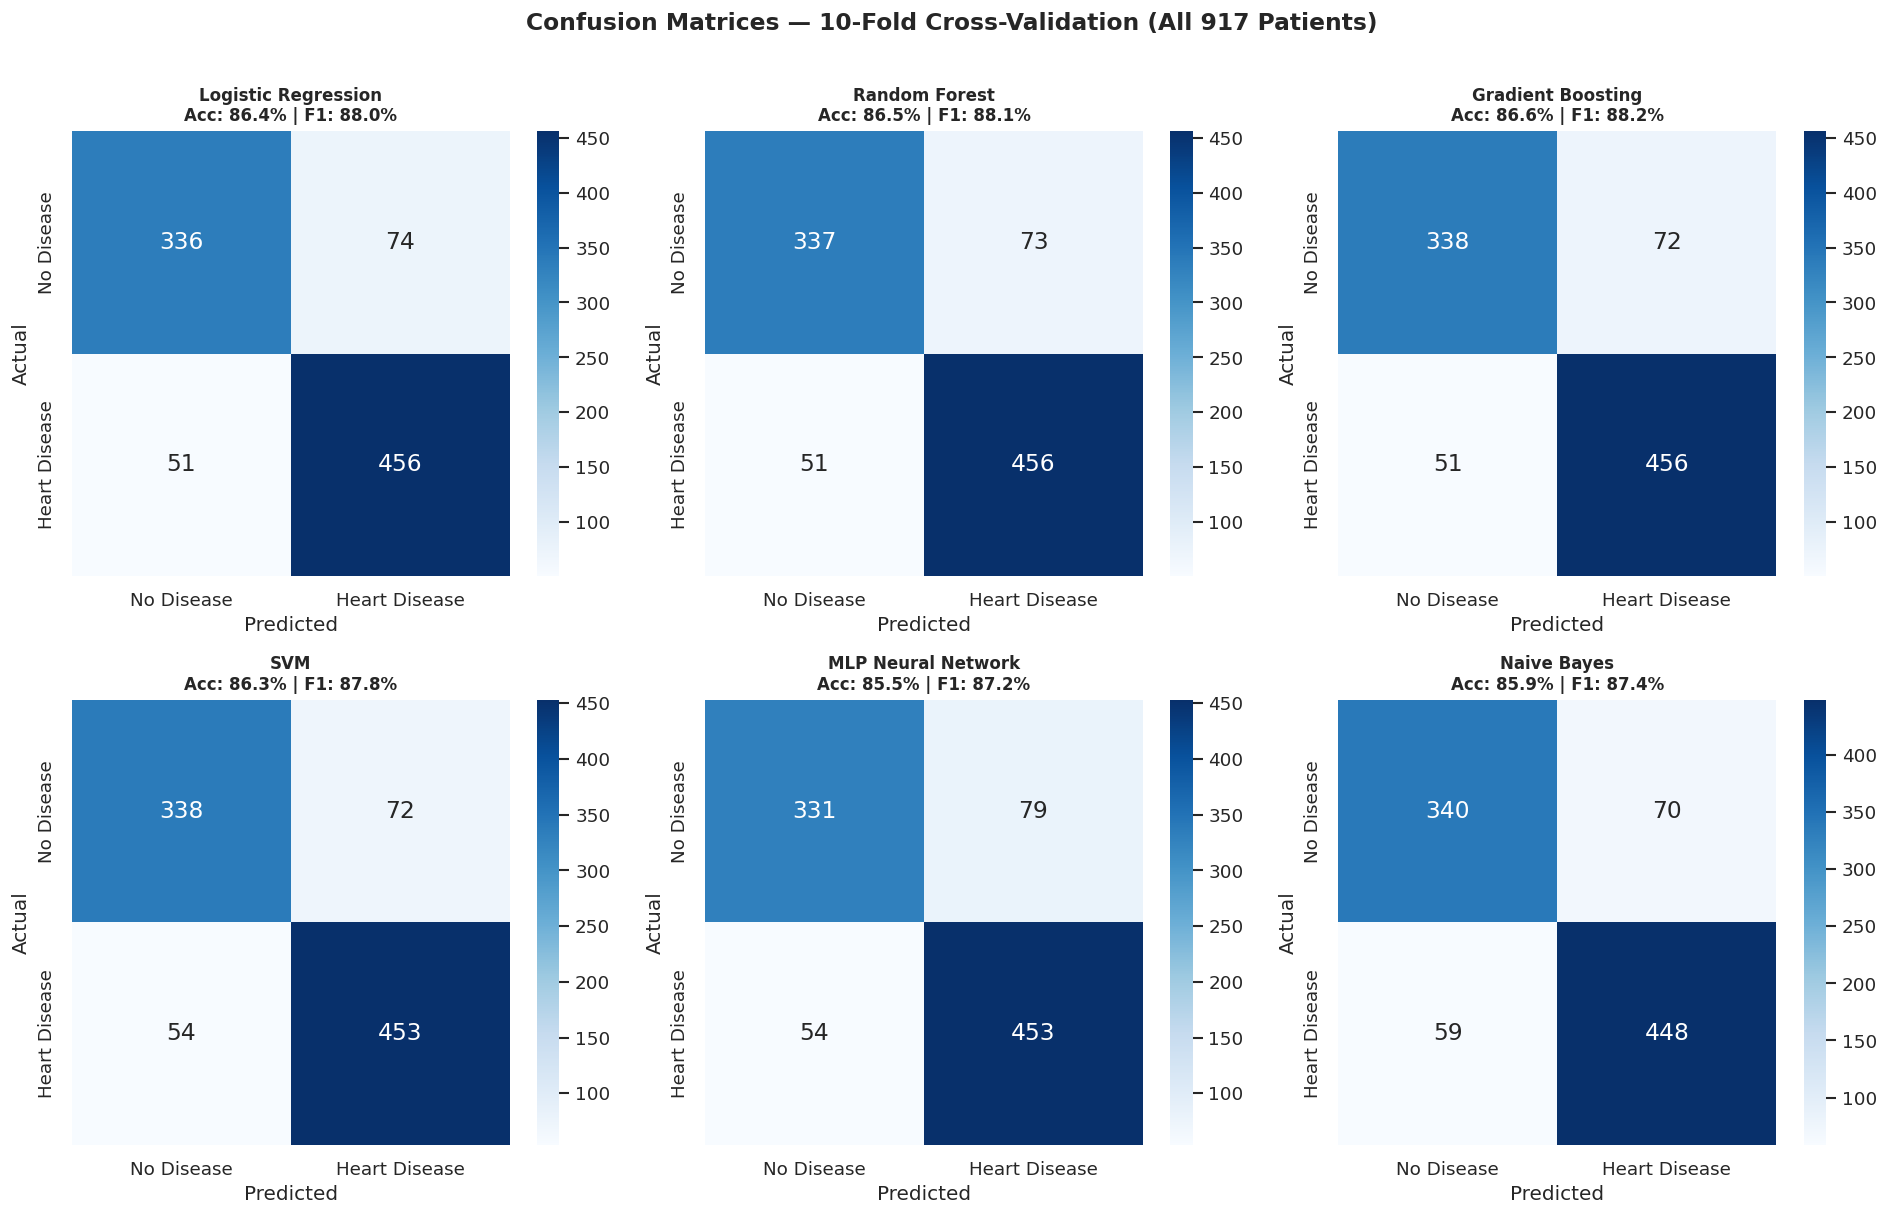

In [29]:
# =====================================================================
# 26. CONFUSION MATRICES
# =====================================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(tuned_models.items()):
    y_pred = cross_val_predict(model, X, y, cv=cv)
    cm = confusion_matrix(y, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No Disease', 'Heart Disease'],
                yticklabels=['No Disease', 'Heart Disease'],
                annot_kws={'size': 14})
    acc = tuned_results[name]['Accuracy'].mean() * 100
    f1 = tuned_results[name]['F1-Score'].mean() * 100
    axes[i].set_title(f'{name}\nAcc: {acc:.1f}% | F1: {f1:.1f}%', fontweight='bold', fontsize=10)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices — 10-Fold Cross-Validation (All 917 Patients)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig10_confusion_matrices.png', bbox_inches='tight')
plt.show()


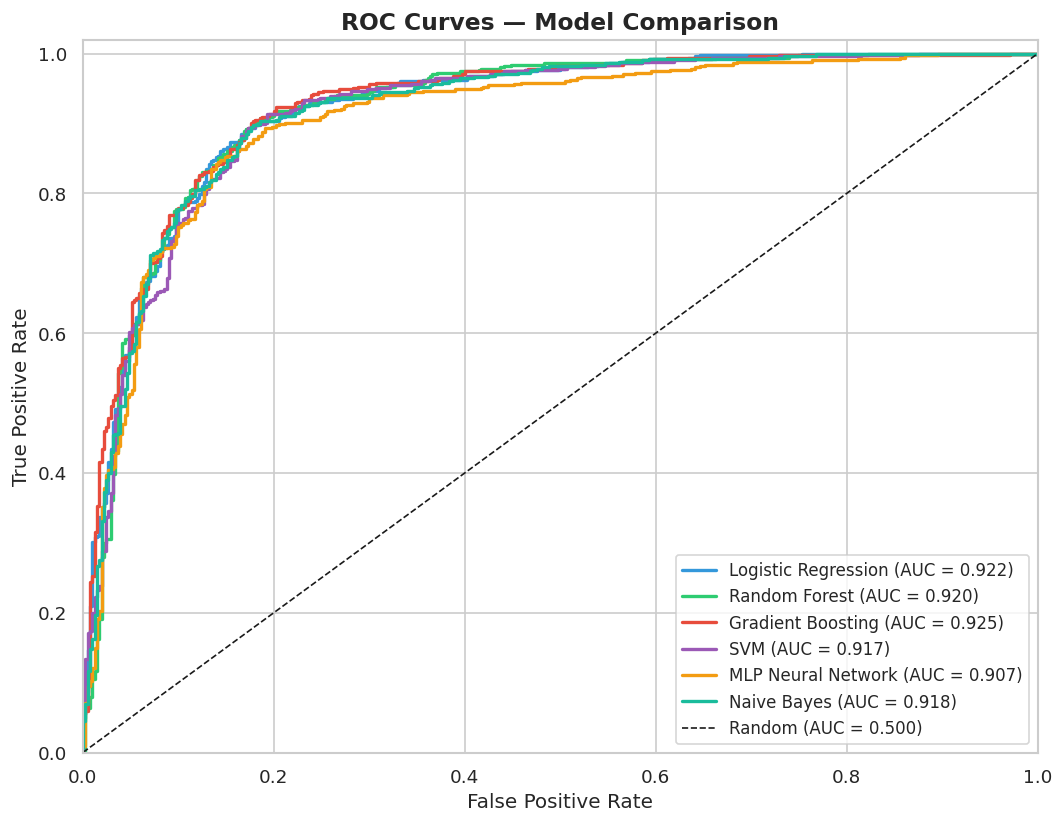

In [30]:
# =====================================================================
# 27. ROC CURVES — ALL MODELS OVERLAID
# =====================================================================
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12', '#1abc9c']

for idx, (name, model) in enumerate(tuned_models.items()):
    if hasattr(model, 'predict_proba'):
        y_proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba')[:, 1]
    else:
        y_proba = cross_val_predict(model, X, y, cv=cv, method='decision_function')

    fpr, tpr, _ = roc_curve(y, y_proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[idx], linewidth=2,
            label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('fig11_roc_curves.png', bbox_inches='tight')
plt.show()


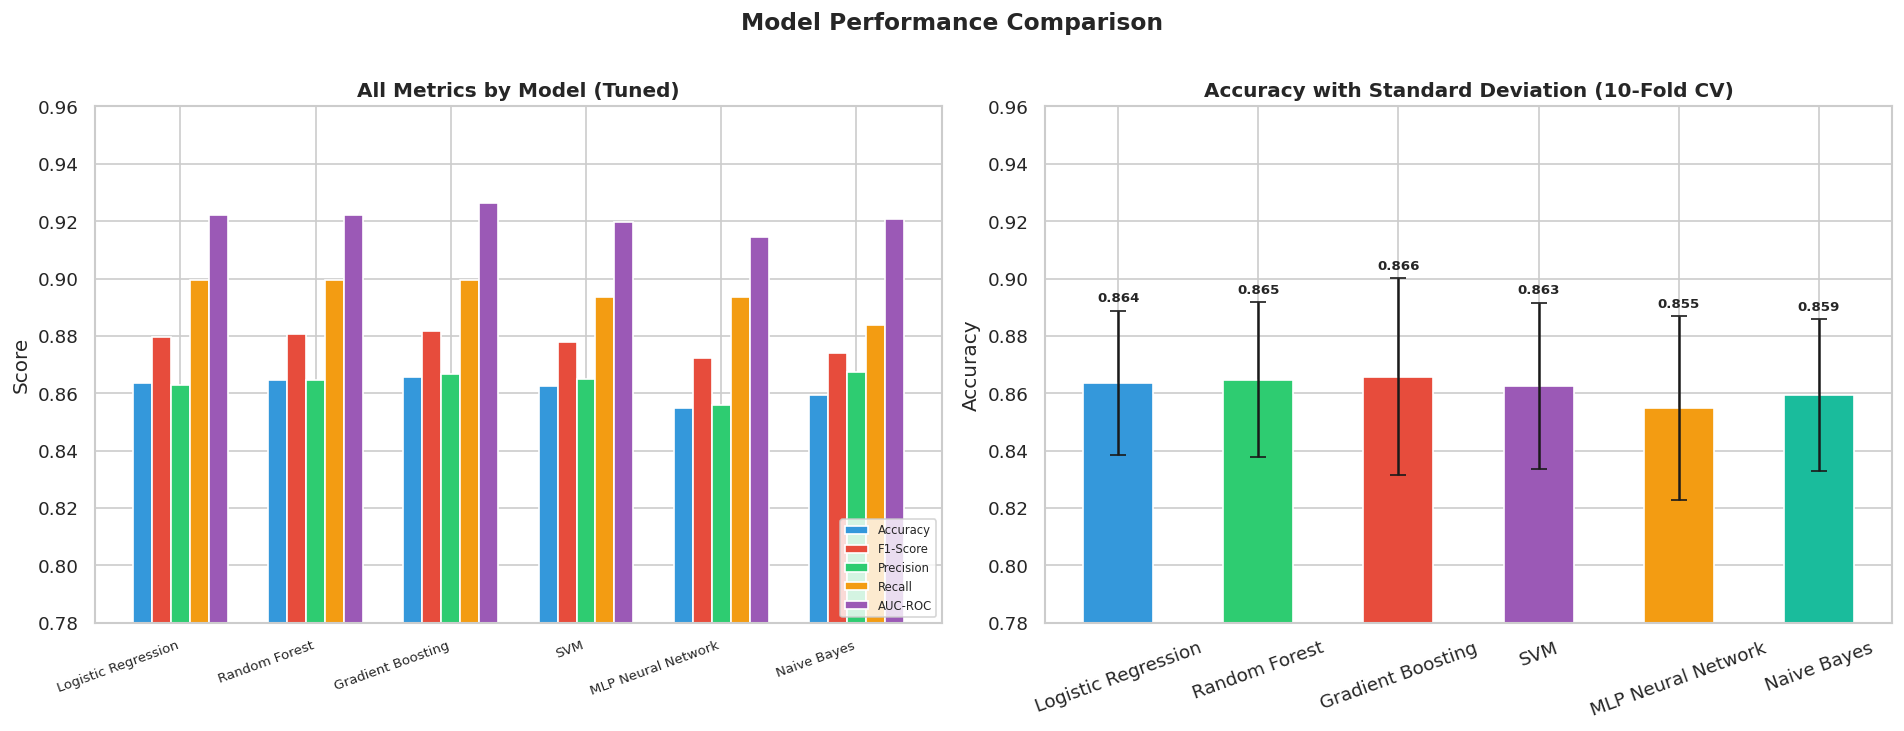

In [31]:
# =====================================================================
# 28. PERFORMANCE COMPARISON BAR CHART
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics_to_plot = ['Accuracy', 'F1-Score', 'Precision', 'Recall', 'AUC-ROC']
colors_metrics = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']

# Chart 1: All metrics side by side (tuned models)
x = np.arange(len(model_names))
width = 0.14

for i, metric in enumerate(metrics_to_plot):
    means = [tuned_results[m][metric].mean() for m in model_names]
    axes[0].bar(x + i * width, means, width, label=metric,
                color=colors_metrics[i], edgecolor='white')

axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(model_names, rotation=20, ha='right', fontsize=8)
axes[0].set_ylabel('Score')
axes[0].set_title('All Metrics by Model (Tuned)', fontweight='bold')
axes[0].set_ylim(0.78, 0.96)
axes[0].legend(fontsize=7, loc='lower right')

# Chart 2: Accuracy with error bars
means = [tuned_results[m]['Accuracy'].mean() for m in model_names]
stds = [tuned_results[m]['Accuracy'].std() for m in model_names]
bars = axes[1].bar(model_names, means, yerr=stds, capsize=5,
                   color=colors, edgecolor='white', width=0.5)
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy with Standard Deviation (10-Fold CV)', fontweight='bold')
axes[1].set_ylim(0.78, 0.96)
axes[1].tick_params(axis='x', rotation=20)
for bar, m, s in zip(bars, means, stds):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.003,
                 f'{m:.3f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig12_performance_comparison.png', bbox_inches='tight')
plt.show()



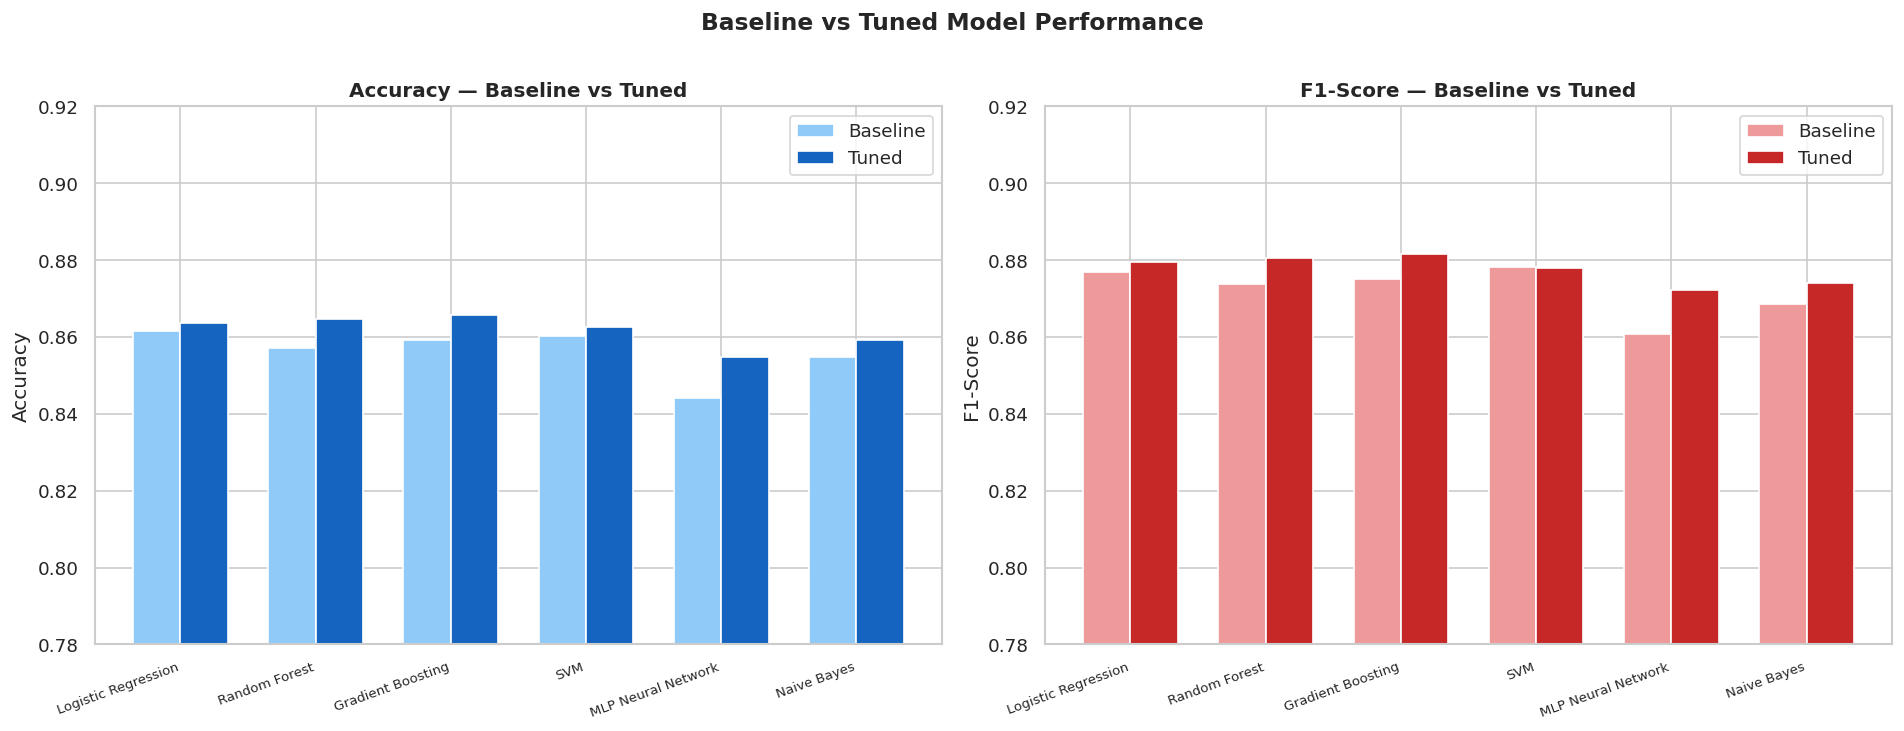

In [32]:
# =====================================================================
# 29. BASELINE vs TUNED COMPARISON CHART
# =====================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
x = np.arange(len(model_names))
w = 0.35
b_acc = [baseline_results[m]['Accuracy'].mean() for m in model_names]
t_acc = [tuned_results[m]['Accuracy'].mean() for m in model_names]

axes[0].bar(x - w/2, b_acc, w, label='Baseline', color='#90CAF9', edgecolor='white')
axes[0].bar(x + w/2, t_acc, w, label='Tuned', color='#1565C0', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=20, ha='right', fontsize=8)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy — Baseline vs Tuned', fontweight='bold')
axes[0].set_ylim(0.78, 0.92)
axes[0].legend()

# F1 comparison
b_f1 = [baseline_results[m]['F1-Score'].mean() for m in model_names]
t_f1 = [tuned_results[m]['F1-Score'].mean() for m in model_names]

axes[1].bar(x - w/2, b_f1, w, label='Baseline', color='#EF9A9A', edgecolor='white')
axes[1].bar(x + w/2, t_f1, w, label='Tuned', color='#C62828', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=20, ha='right', fontsize=8)
axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1-Score — Baseline vs Tuned', fontweight='bold')
axes[1].set_ylim(0.78, 0.92)
axes[1].legend()

plt.suptitle('Baseline vs Tuned Model Performance', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig13_baseline_vs_tuned.png', bbox_inches='tight')
plt.show()



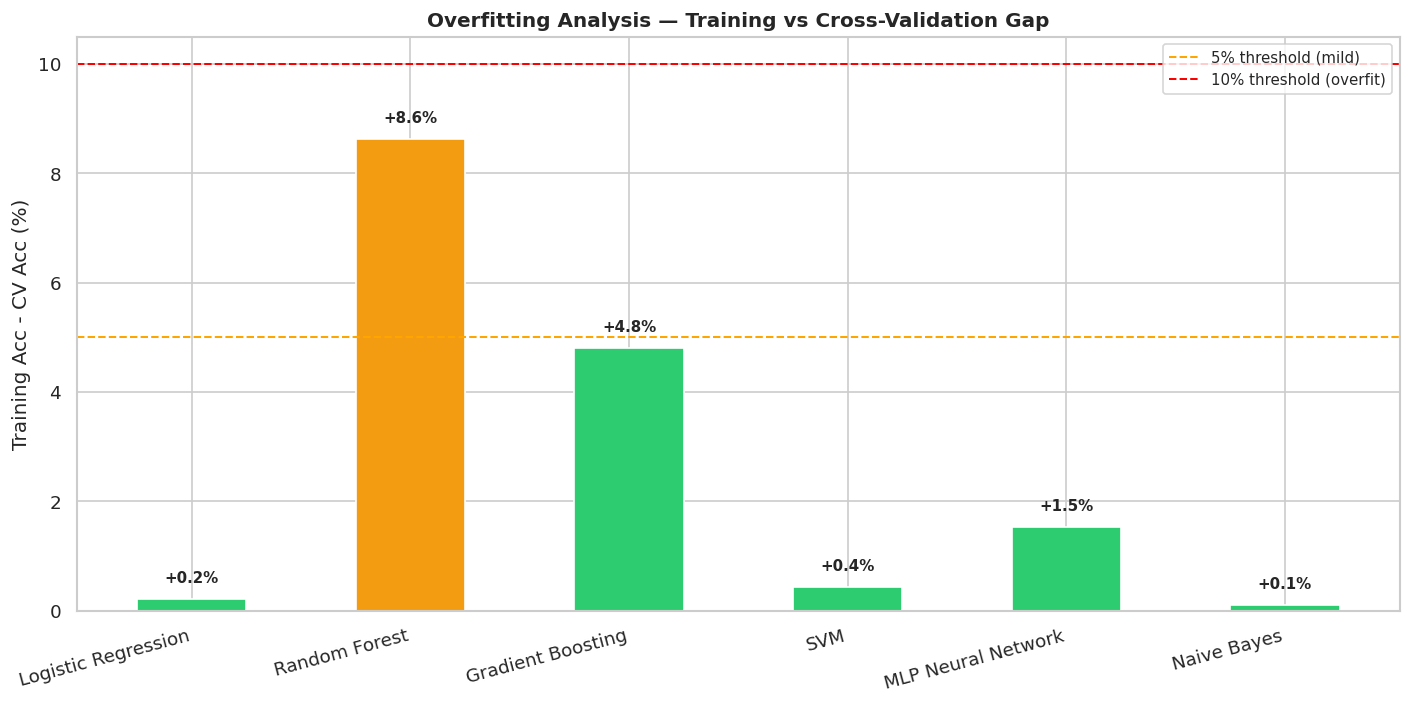

In [33]:
# =====================================================================
# 30. OVERFITTING ANALYSIS CHART
# =====================================================================
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(model_names))
gaps = [overfit_data[m]['gap'] for m in model_names]

bars = ax.bar(x, gaps, color=['#2ecc71' if abs(g) < 5 else '#e74c3c' if abs(g) >= 10
              else '#f39c12' for g in gaps], edgecolor='white', width=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(5, color='orange', linewidth=1.2, linestyle='--', label='5% threshold (mild)')
ax.axhline(10, color='red', linewidth=1.2, linestyle='--', label='10% threshold (overfit)')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylabel('Training Acc - CV Acc (%)')
ax.set_title('Overfitting Analysis — Training vs Cross-Validation Gap', fontweight='bold')
ax.legend(fontsize=9)
for bar, val in zip(bars, gaps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:+.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig14_overfitting_analysis.png', bbox_inches='tight')
plt.show()



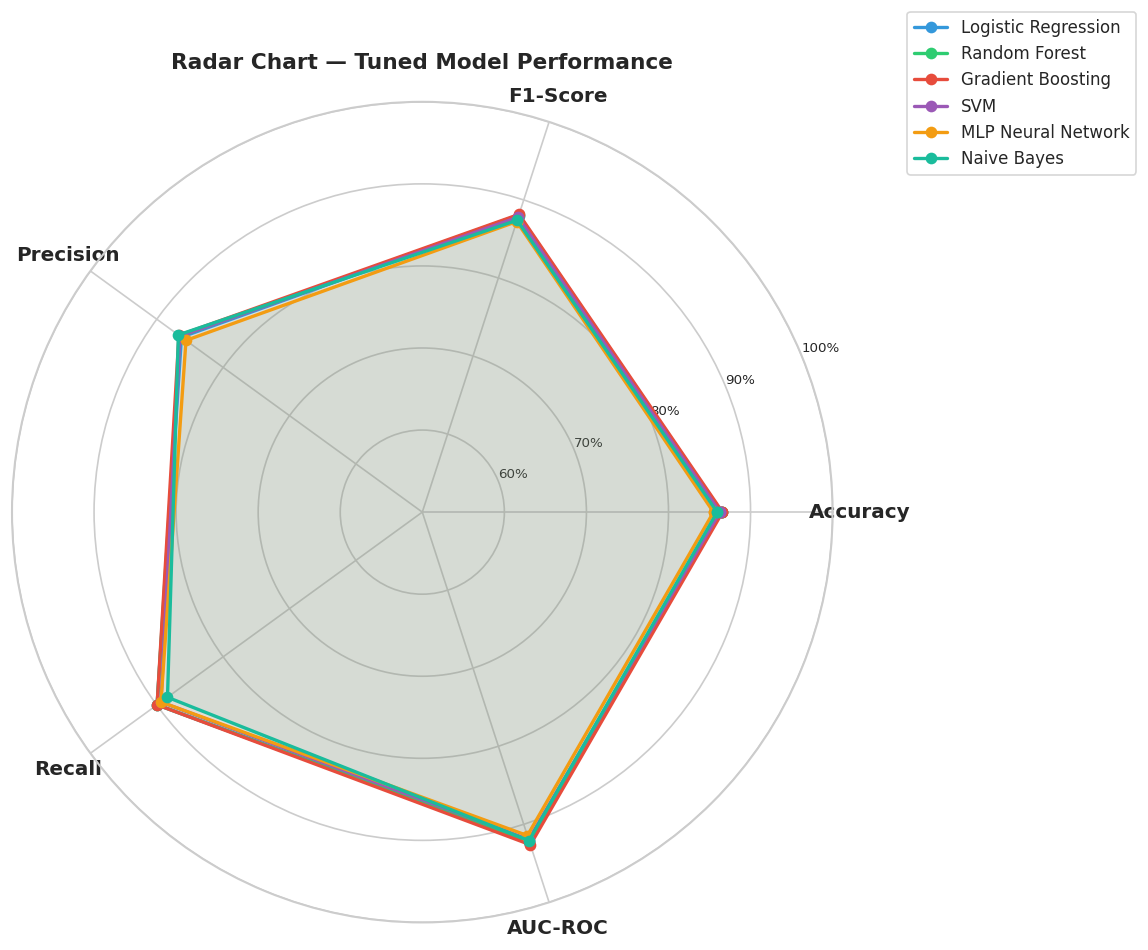

In [34]:
# =====================================================================
# 31. RADAR CHART — ALL TUNED MODELS
# =====================================================================
radar_metrics = ['Accuracy', 'F1-Score', 'Precision', 'Recall', 'AUC-ROC']
N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

for i, name in enumerate(model_names):
    vals = [tuned_results[name][m].mean() * 100 for m in radar_metrics]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', lw=2, color=colors[i], label=name)
    ax.fill(angles, vals, alpha=0.06, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=12, fontweight='bold')
ax.set_ylim(50, 100)
ax.set_yticks([60, 70, 80, 90, 100])
ax.set_yticklabels(['60%', '70%', '80%', '90%', '100%'], fontsize=8)
ax.set_title('Radar Chart — Tuned Model Performance', fontsize=13,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.38, 1.12), fontsize=10)

plt.tight_layout()
plt.savefig('fig15_radar_chart.png', bbox_inches='tight')
plt.show()



FEATURE IMPORTANCE ANALYSIS

Normalized Feature Importance (0 = least, 1 = most):

                   Random Forest  Gradient Boosting  Logistic Regression  Average
ST_Slope_Up               1.0000             1.0000               1.0000   1.0000
ST_Slope_Flat             0.7600             0.0240               0.8900   0.5580
Oldpeak                   0.6580             0.1830               0.6270   0.4890
ExerciseAngina_Y          0.5600             0.1090               0.7970   0.4890
MaxHR                     0.5430             0.1340               0.5160   0.3980
ChestPainType_ATA         0.2400             0.0640               0.8510   0.3850
Sex_M                     0.2380             0.1180               0.7700   0.3750
ChestPainType_NAP         0.1500             0.0920               0.7050   0.3160
FastingBS_1.0             0.1810             0.0720               0.6800   0.3110
Age                       0.4000             0.0500               0.3160   0.2550
Cholesterol   

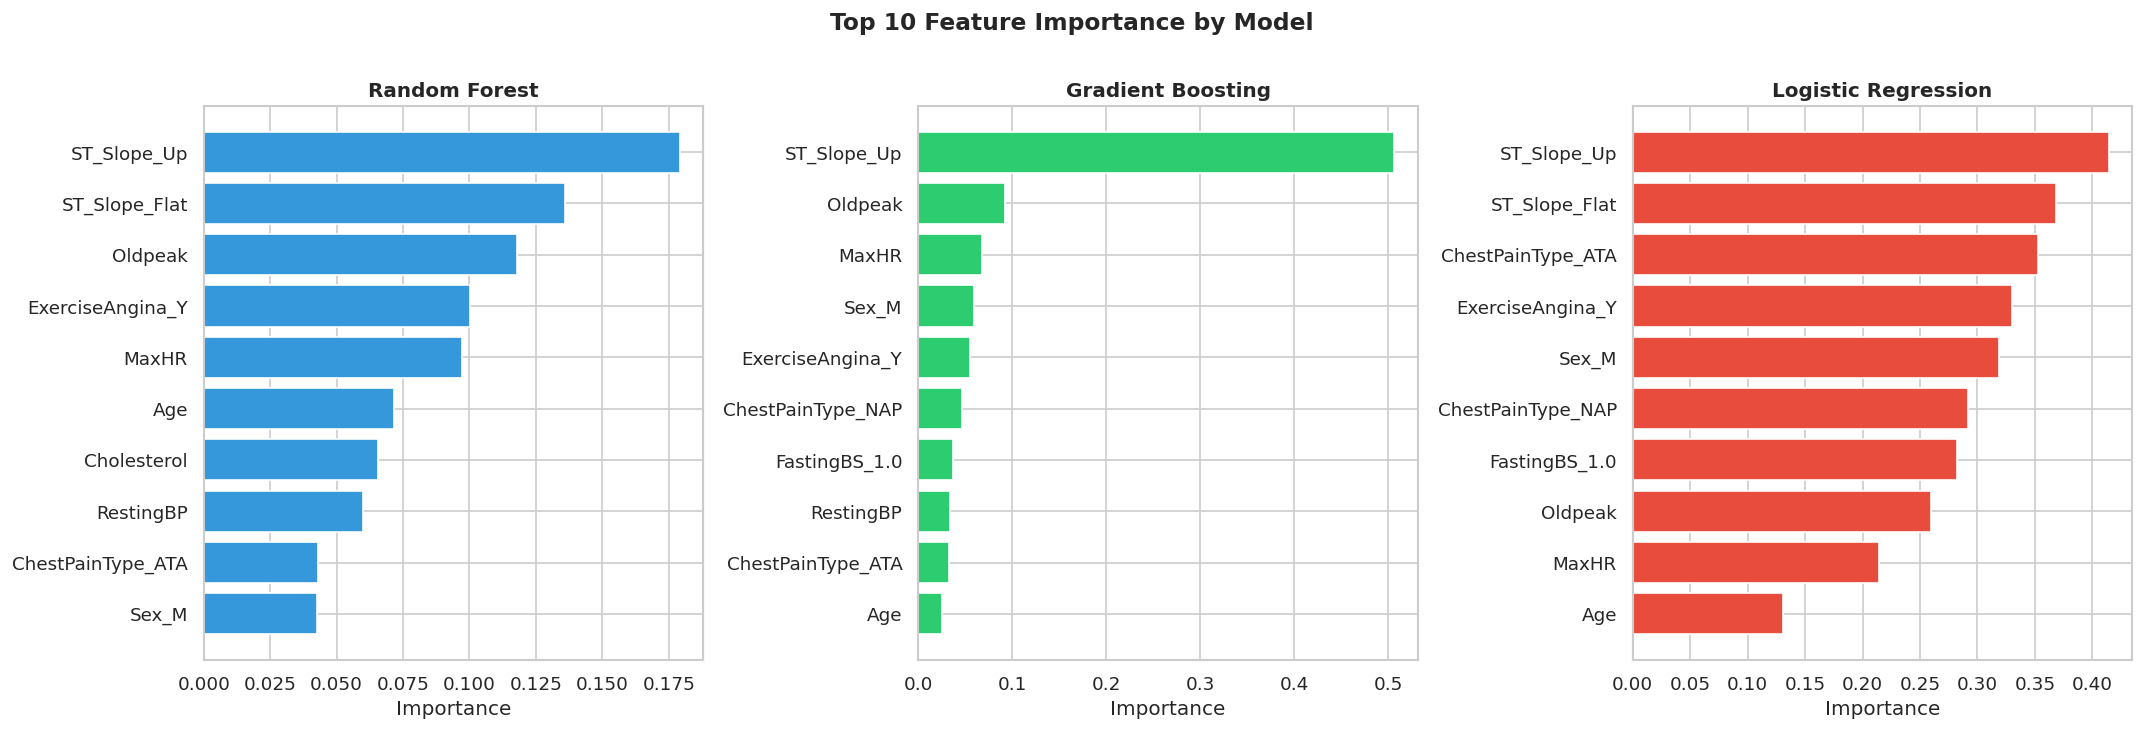

In [35]:

# =====================================================================
# 32. FEATURE IMPORTANCE COMPARISON
# =====================================================================
print(f"\n{'='*70}")
print("FEATURE IMPORTANCE ANALYSIS")
print(f"{'='*70}\n")

feature_names = list(X.columns)

# Random Forest feature importance (built-in)
rf_model = tuned_models['Random Forest']
rf_model.fit(X, y)
rf_importance = pd.Series(rf_model.feature_importances_, index=feature_names)

# Gradient Boosting feature importance (built-in)
gb_model = tuned_models['Gradient Boosting']
gb_model.fit(X, y)
gb_importance = pd.Series(gb_model.feature_importances_, index=feature_names)

# Logistic Regression coefficients (absolute values)
lr_model = tuned_models['Logistic Regression']
lr_model.fit(X, y)
lr_importance = pd.Series(np.abs(lr_model.named_steps['model'].coef_[0]), index=feature_names)

# Combine and normalize
importance_df = pd.DataFrame({
    'Random Forest': rf_importance,
    'Gradient Boosting': gb_importance,
    'Logistic Regression': lr_importance
})
importance_df = importance_df.div(importance_df.max())

importance_df['Average'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values('Average', ascending=False)

print("Normalized Feature Importance (0 = least, 1 = most):\n")
print(importance_df.round(3).to_string())

# Plot top 10 features
top_n = min(10, len(importance_df))
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
model_importance = {
    'Random Forest': rf_importance.sort_values(ascending=True).tail(top_n),
    'Gradient Boosting': gb_importance.sort_values(ascending=True).tail(top_n),
    'Logistic Regression': lr_importance.sort_values(ascending=True).tail(top_n)
}

for i, (name, imp) in enumerate(model_importance.items()):
    axes[i].barh(imp.index, imp.values, color=colors[i], edgecolor='white')
    axes[i].set_title(f'{name}', fontweight='bold')
    axes[i].set_xlabel('Importance')

plt.suptitle(f'Top {top_n} Feature Importance by Model',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig16_feature_importance.png', bbox_inches='tight')
plt.show()


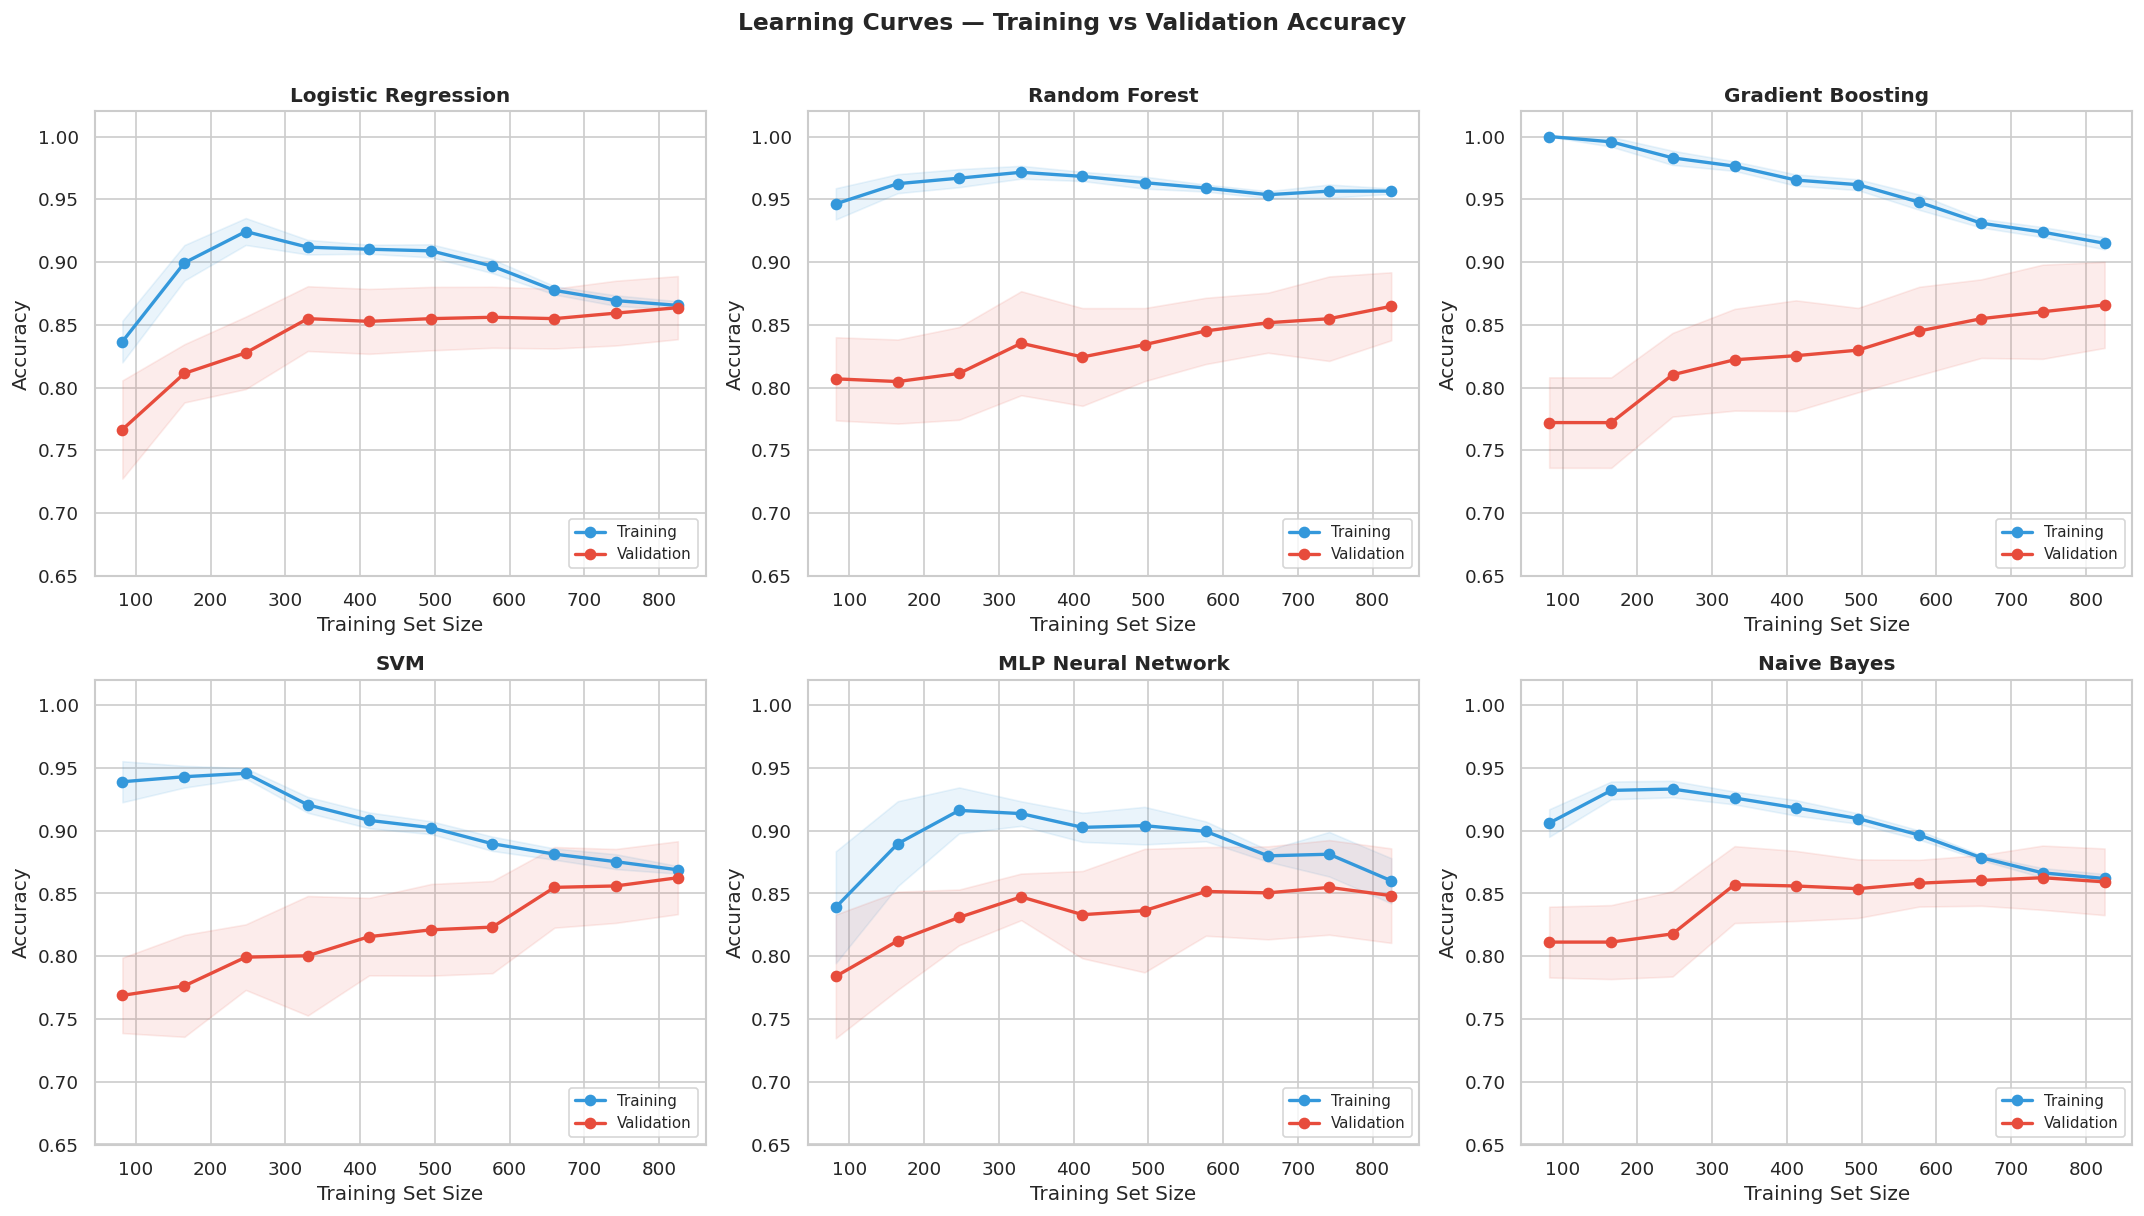

In [36]:
# =====================================================================
# 33. LEARNING CURVES
# =====================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(tuned_models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y, cv=cv,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy', random_state=RANDOM_STATE
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    axes[i].fill_between(train_sizes, train_mean - train_std,
                         train_mean + train_std, alpha=0.1, color='#3498db')
    axes[i].fill_between(train_sizes, val_mean - val_std,
                         val_mean + val_std, alpha=0.1, color='#e74c3c')
    axes[i].plot(train_sizes, train_mean, 'o-', color='#3498db',
                 label='Training', linewidth=2)
    axes[i].plot(train_sizes, val_mean, 'o-', color='#e74c3c',
                 label='Validation', linewidth=2)
    axes[i].set_title(f'{name}', fontweight='bold')
    axes[i].set_xlabel('Training Set Size')
    axes[i].set_ylabel('Accuracy')
    axes[i].legend(loc='lower right', fontsize=9)
    axes[i].set_ylim(0.65, 1.02)

plt.suptitle('Learning Curves — Training vs Validation Accuracy',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig17_learning_curves.png', bbox_inches='tight')
plt.show()


In [37]:
# =====================================================================
# 34. CLASSIFICATION REPORTS
# =====================================================================
print(f"\n{'='*70}")
print("DETAILED CLASSIFICATION REPORTS (Tuned Models)")
print(f"{'='*70}")

for name, model in tuned_models.items():
    y_pred = cross_val_predict(model, X, y, cv=cv)
    print(f"\n{name}:")
    print(classification_report(y, y_pred,
                                target_names=['No Disease', 'Heart Disease']))



DETAILED CLASSIFICATION REPORTS (Tuned Models)

Logistic Regression:
               precision    recall  f1-score   support

   No Disease       0.87      0.82      0.84       410
Heart Disease       0.86      0.90      0.88       507

     accuracy                           0.86       917
    macro avg       0.86      0.86      0.86       917
 weighted avg       0.86      0.86      0.86       917


Random Forest:
               precision    recall  f1-score   support

   No Disease       0.87      0.82      0.84       410
Heart Disease       0.86      0.90      0.88       507

     accuracy                           0.86       917
    macro avg       0.87      0.86      0.86       917
 weighted avg       0.86      0.86      0.86       917


Gradient Boosting:
               precision    recall  f1-score   support

   No Disease       0.87      0.82      0.85       410
Heart Disease       0.86      0.90      0.88       507

     accuracy                           0.87       917
    ma

In [38]:
# =====================================================================
# 35. McNEMAR'S TEST — PAIRWISE MODEL COMPARISON
# =====================================================================
print(f"\n{'='*70}")
print("McNEMAR'S TEST — Pairwise Model Comparison")
print(f"{'='*70}")
print("(Tests whether two models make significantly different errors)\n")

predictions = {}
for name, model in tuned_models.items():
    predictions[name] = cross_val_predict(model, X, y, cv=cv)

print(f"{'Model A':<25}{'Model B':<25}{'Chi-sq':<10}{'p-value':<10}{'Significant?':<12}")
print("-" * 82)

for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        pred_a = predictions[model_names[i]]
        pred_b = predictions[model_names[j]]

        correct_a = (pred_a == y).astype(int)
        correct_b = (pred_b == y).astype(int)

        n01 = ((correct_a == 0) & (correct_b == 1)).sum()
        n10 = ((correct_a == 1) & (correct_b == 0)).sum()

        if (n01 + n10) > 0:
            chi2 = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)
            p_val = 1 - stats.chi2.cdf(chi2, df=1)
        else:
            chi2 = 0.0
            p_val = 1.0

        sig = "Yes (p<0.05)" if p_val < 0.05 else "No"
        print(f"{model_names[i]:<25}{model_names[j]:<25}{chi2:<10.4f}{p_val:<10.4f}{sig:<12}")



McNEMAR'S TEST — Pairwise Model Comparison
(Tests whether two models make significantly different errors)

Model A                  Model B                  Chi-sq    p-value   Significant?
----------------------------------------------------------------------------------
Logistic Regression      Random Forest            0.0000    1.0000    No          
Logistic Regression      Gradient Boosting        0.0161    0.8989    No          
Logistic Regression      SVM                      0.0000    1.0000    No          
Logistic Regression      MLP Neural Network       1.5312    0.2159    No          
Logistic Regression      Naive Bayes              0.4500    0.5023    No          
Random Forest            Gradient Boosting        0.0000    1.0000    No          
Random Forest            SVM                      0.0200    0.8875    No          
Random Forest            MLP Neural Network       1.1228    0.2893    No          
Random Forest            Naive Bayes              0.3019    0.

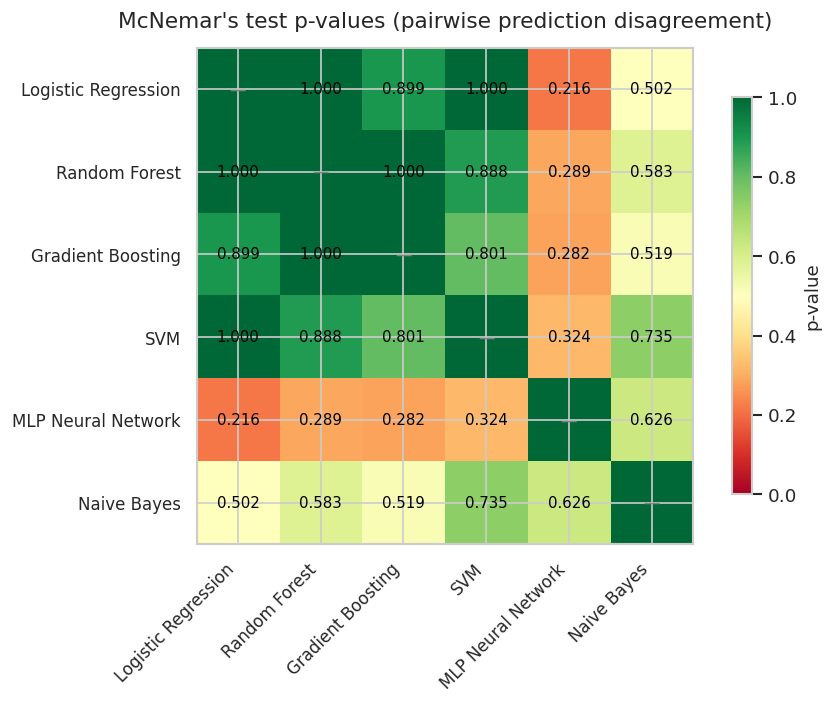

In [39]:
# =====================================================================
# 35b. HEATMAP — McNemar's test p-values
# =====================================================================
n = len(model_names)
p_matrix_mc = np.ones((n, n))

for i in range(n):
    for j in range(i+1, n):
        pred_a = predictions[model_names[i]]
        pred_b = predictions[model_names[j]]

        correct_a = (pred_a == y).astype(int)
        correct_b = (pred_b == y).astype(int)

        n01 = ((correct_a == 0) & (correct_b == 1)).sum()
        n10 = ((correct_a == 1) & (correct_b == 0)).sum()

        if (n01 + n10) > 0:
            chi2 = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)
            p_val = 1 - stats.chi2.cdf(chi2, df=1)
        else:
            p_val = 1.0

        p_matrix_mc[i, j] = p_val
        p_matrix_mc[j, i] = p_val

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(p_matrix_mc, cmap='RdYlGn', vmin=0, vmax=1)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(model_names, fontsize=10)

for i in range(n):
    for j in range(n):
        if i != j:
            ax.text(j, i, f'{p_matrix_mc[i,j]:.3f}', ha='center', va='center',
                    fontsize=9, fontweight='bold' if p_matrix_mc[i,j] < 0.05 else 'normal',
                    color='white' if p_matrix_mc[i,j] < 0.15 else 'black')
        else:
            ax.text(j, i, '—', ha='center', va='center', fontsize=10, color='grey')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('p-value', fontsize=11)

ax.set_title("McNemar's test p-values (pairwise prediction disagreement)", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('fig_mcnemar_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [40]:
# =====================================================================
# 36. FINAL SUMMARY
# =====================================================================
print(f"\n{'='*70}")
print("FINAL SUMMARY")
print(f"{'='*70}")

best_model = max(tuned_results, key=lambda x: tuned_results[x]['F1-Score'].mean())
print(f"\nBest performing model: {best_model}")
print(f"  Accuracy:  {tuned_results[best_model]['Accuracy'].mean():.4f}")
print(f"  F1-Score:  {tuned_results[best_model]['F1-Score'].mean():.4f}")
print(f"  AUC-ROC:   {tuned_results[best_model]['AUC-ROC'].mean():.4f}")

print(f"\nAll models ranked by F1-Score:")
ranked = sorted(tuned_results.items(), key=lambda x: x[1]['F1-Score'].mean(), reverse=True)
for rank, (name, metrics) in enumerate(ranked, 1):
    print(f"  {rank}. {name}: F1 = {metrics['F1-Score'].mean():.4f}, "
          f"Acc = {metrics['Accuracy'].mean():.4f}, "
          f"AUC = {metrics['AUC-ROC'].mean():.4f}")

print(f"\nBest Hyperparameters:")
for name, params in best_params_all.items():
    print(f"  {name:22s}: {params}")

print(f"\nFiles generated:")
print(f"  - heart_clean.csv           (cleaned dataset)")
print(f"  - confusion_matrices.png    (all 6 models)")
print(f"  - roc_curves.png            (overlaid ROC curves)")
print(f"  - performance_comparison.png")
print(f"  - baseline_vs_tuned.png     (improvement comparison)")
print(f"  - overfitting_analysis.png  (train vs CV gap)")
print(f"  - radar_chart.png           (multi-metric radar)")
print(f"  - feature_importance.png    (3 models compared)")
print(f"  - learning_curves.png       (all 6 models)")


FINAL SUMMARY

Best performing model: Gradient Boosting
  Accuracy:  0.8658
  F1-Score:  0.8815
  AUC-ROC:   0.9262

All models ranked by F1-Score:
  1. Gradient Boosting: F1 = 0.8815, Acc = 0.8658, AUC = 0.9262
  2. Random Forest: F1 = 0.8806, Acc = 0.8647, AUC = 0.9220
  3. Logistic Regression: F1 = 0.8795, Acc = 0.8636, AUC = 0.9222
  4. SVM: F1 = 0.8779, Acc = 0.8626, AUC = 0.9195
  5. Naive Bayes: F1 = 0.8740, Acc = 0.8593, AUC = 0.9209
  6. MLP Neural Network: F1 = 0.8723, Acc = 0.8549, AUC = 0.9144

Best Hyperparameters:
  Logistic Regression   : {'model__C': 0.01, 'model__solver': 'lbfgs'}
  Random Forest         : {'max_depth': 15, 'min_samples_leaf': 2, 'n_estimators': 100}
  Gradient Boosting     : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
  SVM                   : {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
  MLP Neural Network    : {'model__activation': 'relu', 'model__alpha': 0.0001, 'model__hidden_layer_sizes': (128, 64)}
  Nai